# Feature Engineering

In [197]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv("../data/processed_data.csv")
df

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,metformin-pioglitazone,change,diabetesMed,readmitted
0,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,Other,Diabetes,Other,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,Yes,Yes,>30
1,86047875,African American,Female,[20-30),1,1,7,2,11,5,13,2,0,1,Other,Diabetes,Other,6,Not measured,Not measured,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No
2,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,Other,Diabetes,Circulatory,7,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,Yes,Yes,No
3,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,Neoplasms,Neoplasms,Diabetes,5,Not measured,Not measured,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,Yes,Yes,No
4,82637451,Caucasian,Male,[50-60),2,1,2,3,31,6,16,0,0,0,Circulatory,Circulatory,Diabetes,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,Yes,>30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68624,183087545,Caucasian,Female,[70-80),1,1,7,9,50,2,33,0,0,0,Digestive,Digestive,Diabetes,9,Not measured,>7,No,No,No,No,No,No,No,Up,No,No,No,No,No,No,No,Steady,No,No,No,Yes,Yes,>30
68625,188574944,Other,Female,[40-50),1,1,7,14,73,6,26,0,1,0,Genitourinary,Genitourinary,Respiratory,9,Not measured,>8,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Up,No,No,No,Yes,Yes,>30
68626,140199494,Other,Female,[60-70),1,1,7,2,46,6,17,1,1,1,Injury,Genitourinary,Circulatory,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,Yes,>30
68627,120975314,Caucasian,Female,[80-90),1,1,7,5,76,1,22,0,1,0,Other,Other,Other,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,Yes,Yes,No


In [198]:
# remove duplicates based on patient_nbr and drop the patient_nbr column
df = df.drop_duplicates(subset="patient_nbr", keep="first")

# number of rows dropped
print(f"Number of rows dropped: {df.shape[0]}")

# then we drop the patient_nbr column as it is no longer needed and it is not a feature that we want to use for training the model
df = df.drop(columns=["patient_nbr"])

Number of rows dropped: 68629


In [199]:
df

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,Other,Diabetes,Other,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,Yes,Yes,>30
1,African American,Female,[20-30),1,1,7,2,11,5,13,2,0,1,Other,Diabetes,Other,6,Not measured,Not measured,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No
2,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,Other,Diabetes,Circulatory,7,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,Yes,Yes,No
3,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,Neoplasms,Neoplasms,Diabetes,5,Not measured,Not measured,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,Yes,Yes,No
4,Caucasian,Male,[50-60),2,1,2,3,31,6,16,0,0,0,Circulatory,Circulatory,Diabetes,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,Yes,>30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68624,Caucasian,Female,[70-80),1,1,7,9,50,2,33,0,0,0,Digestive,Digestive,Diabetes,9,Not measured,>7,No,No,No,No,No,No,No,Up,No,No,No,No,No,No,No,Steady,No,No,No,Yes,Yes,>30
68625,Other,Female,[40-50),1,1,7,14,73,6,26,0,1,0,Genitourinary,Genitourinary,Respiratory,9,Not measured,>8,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Up,No,No,No,Yes,Yes,>30
68626,Other,Female,[60-70),1,1,7,2,46,6,17,1,1,1,Injury,Genitourinary,Circulatory,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,Yes,>30
68627,Caucasian,Female,[80-90),1,1,7,5,76,1,22,0,1,0,Other,Other,Other,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,Yes,Yes,No


In this part of the notebook we will be encoding all the variables that need encoding to make them ready for the next steps: data reduction, clusetring and modelling.

Only the variables that need feature engineering will be included in this section, normal numerical variables will not be touched as they have been already cleaned in the 'data_processing.ipynb' file.

### Race Encoding:

In [200]:
# race percentage of each category
race_counts = df["race"].value_counts(normalize=True) * 100
print(race_counts)
# since the race columns of asian and hispanic are very small we will add them to the other category

df["race"] = df["race"].replace({
    "Asian": "Other",
    "Hispanic": "Other"
})
# check new values of race
race_counts = df["race"].value_counts(normalize=True) * 100
print(race_counts)
# we us one hot encoding to encode the race column as it is a categorical variable and we want to convert it into a format that can be used by machine learning algorithms

df = pd.get_dummies(df, columns=["race"], prefix="race", dtype=int)

race_cols = [col for col in df.columns if col.startswith("race_")]
print("Columns:", race_cols)
print("Counts per race category:\n", df[race_cols].sum())
print("First 5 rows:\n", df[race_cols].head())

race
Caucasian           76.996605
African American    18.454298
Hispanic             2.152151
Other                1.690248
Asian                0.706698
Name: proportion, dtype: float64
race
Caucasian           76.996605
African American    18.454298
Other                4.549097
Name: proportion, dtype: float64
Columns: ['race_African American', 'race_Caucasian', 'race_Other']
Counts per race category:
 race_African American    12665
race_Caucasian           52842
race_Other                3122
dtype: int64
First 5 rows:
    race_African American  race_Caucasian  race_Other
0                      0               1           0
1                      1               0           0
2                      0               1           0
3                      0               1           0
4                      0               1           0


### Gender, age, admission_type_id Encoding:

In [201]:
# encoding gender using map function using binary encoding where male is 1 and female is 0 as it is a binary variable and we want to convert it into a format that can be used by machine learning algorithms
df["gender"] = df["gender"].map({"Male":1, "Female":0})
print("Unique values:", df["gender"].unique())  


# encoding age using midpoint conversion where we take the midpoint of the age range as the value for that age group
age_map = {
    "[0-10)":5,"[10-20)":15,"[20-30)":25,"[30-40)":35,
    "[40-50)":45,"[50-60)":55,"[60-70)":65,"[70-80)":75,
    "[80-90)":85,"[90-100)":95
}

df["age"] = df["age"].map(age_map)
print("Unique values (midpoints):", sorted(df["age"].unique()))

# loking for the number of differebt unique values in admission_type_id column
# print(df["admission_type_id"].value_counts())
# we will replace the values in the admission_type_id column with more meaningful values as follows: we will replace 1 with "Emergency", 2 with "Urgent", 3 with "Elective", and the rest of the values with "Other" as they are not very common and we want to group them together
df["admission_type_id"] = df["admission_type_id"].replace({
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Other",
    5: "Other",
    6: "Other",
    7: "Other",
    8: "Other"
})


df = pd.get_dummies(df, columns=["admission_type_id"], prefix="adm_type", dtype=int)
adm_type_cols = [col for col in df.columns if col.startswith("adm_type_")]
print("One-hot encoded columns:", adm_type_cols)
print("Counts per admission type:\n", df[adm_type_cols].sum())
print("First 5 rows:\n", df[adm_type_cols].head())


Unique values: [0 1]
Unique values (midpoints): [5, 15, 25, 35, 45, 55, 65, 75, 85, 95]
One-hot encoded columns: ['adm_type_Elective', 'adm_type_Emergency', 'adm_type_Other', 'adm_type_Urgent']
Counts per admission type:
 adm_type_Elective     13397
adm_type_Emergency    35121
adm_type_Other         7838
adm_type_Urgent       12273
dtype: int64
First 5 rows:
    adm_type_Elective  adm_type_Emergency  adm_type_Other  adm_type_Urgent
0                  0                   1               0                0
1                  0                   1               0                0
2                  0                   1               0                0
3                  0                   1               0                0
4                  0                   0               0                1


In [202]:
# unique identifiers in the discharge_disposition_id column
print(df["discharge_disposition_id"].value_counts())

discharge_disposition_id
1     42230
3      8513
6      8081
18     2426
2      1476
22     1398
11     1053
5       865
25      732
4       495
7       386
23      254
13      242
14      215
28       89
8        71
15       40
24       25
9         9
17        8
10        6
19        6
27        3
16        3
12        2
20        1
Name: count, dtype: int64


### discharge_disposition_id encoding:

In [203]:
# drop rows with discharge_disposition_id in [11, 13, 14, 19, 20, 21] as they represent death or hospice care which are not relevant for our prediction task
death_hospice_ids = [11, 13, 14, 19, 20, 21]
df = df[~df["discharge_disposition_id"].isin(death_hospice_ids)]

# mapping discharge_disposition_id to meaningful categories based on the UCI dataset documentation, with less common ones grouped as 'Other'
discharge_map = {
    1:  "Home",
    3:  "Skilled_Nursing",
    6:  "Home_Health",
    18: "Other_Care",
    2:  "Short_Hospital",
    22: "Rehab_Facility",
    5:  "Transfer_Other",
    25: "Other_Facility",
    4:  "Hospital_Transfer",
    7:  "Emergency_Transfer"

   
}

df["discharge_disposition_id"] = df["discharge_disposition_id"].map(discharge_map).fillna("Other")

# verify the mapping
print(df["discharge_disposition_id"].value_counts())


df = pd.get_dummies(df, columns=["discharge_disposition_id"], prefix="discharge", dtype=int)

# verification
discharge_cols = [col for col in df.columns if col.startswith("discharge_")]
print("Columns:", discharge_cols)
print("Counts per discharge category:\n", df[discharge_cols].sum())
print("First 5 rows:\n", df[discharge_cols].head())

discharge_disposition_id
Home                  42230
Skilled_Nursing        8513
Home_Health            8081
Other_Care             2426
Short_Hospital         1476
Rehab_Facility         1398
Transfer_Other          865
Other_Facility          732
Other                   510
Hospital_Transfer       495
Emergency_Transfer      386
Name: count, dtype: int64
Columns: ['discharge_Emergency_Transfer', 'discharge_Home', 'discharge_Home_Health', 'discharge_Hospital_Transfer', 'discharge_Other', 'discharge_Other_Care', 'discharge_Other_Facility', 'discharge_Rehab_Facility', 'discharge_Short_Hospital', 'discharge_Skilled_Nursing', 'discharge_Transfer_Other']
Counts per discharge category:
 discharge_Emergency_Transfer      386
discharge_Home                  42230
discharge_Home_Health            8081
discharge_Hospital_Transfer       495
discharge_Other                   510
discharge_Other_Care             2426
discharge_Other_Facility          732
discharge_Rehab_Facility         1398
disch

### admission_source_id encoding:

In [204]:
# unique values in admission_source_id column
print(df["admission_source_id"].value_counts())

admission_source_id
7     36125
1     20792
17     4688
4      2335
6      1479
2       844
5       506
20      152
3       129
9        36
8        10
10        6
22        4
14        2
25        2
11        1
13        1
Name: count, dtype: int64


In [205]:
admission_source_map = {
    1:  "Physician_Referral",
    2:  "Clinic_Referral",
    3:  "Other",
    4:  "Hospital_Transfer",
    5:  "Transfer_SNF",
    6:  "Health_Facility_Transfer",
    7:  "Emergency_Room",
    8:  "Other",
    9:  "Other",
    10: "Other",
    11: "Other",
    12: "Other",
    13: "Other",
    14: "Other",
    15: "Other",
    16: "Other",
    17: "Clinic_Referral_Transfer"
}
df["admission_source_id"] = df["admission_source_id"].map(admission_source_map)

# One-hot encode as numeric
df = pd.get_dummies(df, columns=["admission_source_id"], prefix="source", dtype=int)

# Verification
source_cols = [col for col in df.columns if col.startswith("source_")]
print("Columns:", source_cols)
print("Counts per source category:\n", df[source_cols].sum())
print("First 5 rows:\n", df[source_cols].head())

Columns: ['source_Clinic_Referral', 'source_Clinic_Referral_Transfer', 'source_Emergency_Room', 'source_Health_Facility_Transfer', 'source_Hospital_Transfer', 'source_Other', 'source_Physician_Referral', 'source_Transfer_SNF']
Counts per source category:
 source_Clinic_Referral               844
source_Clinic_Referral_Transfer     4688
source_Emergency_Room              36125
source_Health_Facility_Transfer     1479
source_Hospital_Transfer            2335
source_Other                         185
source_Physician_Referral          20792
source_Transfer_SNF                  506
dtype: int64
First 5 rows:
    source_Clinic_Referral  source_Clinic_Referral_Transfer  \
0                       0                                0   
1                       0                                0   
2                       0                                0   
3                       0                                0   
4                       1                                0   

   source_Emerg

Creating a new feature of total visits as it might add valuable information

In [206]:
df.insert(
    df.columns.get_loc("number_inpatient") + 1,
    "total_visits",
    df["number_outpatient"] + df["number_emergency"] + df["number_inpatient"]
)

### diag_1, diag_2 and diag_3 encoding:

In [207]:
# the different unique values in diag1
print(df["diag_1"].value_counts())

# the different unique values in diag2
print(df["diag_2"].value_counts())

# the different unique values in diag3
print(df["diag_3"].value_counts())






diag_1
Circulatory        20757
Other              11660
Respiratory         9165
Digestive           6254
Diabetes            5142
Injury              4485
Musculoskeletal     3872
Genitourinary       3342
Neoplasms           2435
Name: count, dtype: int64
diag_2
Circulatory        21493
Other              17420
Diabetes            8916
Respiratory         6753
Genitourinary       5207
Digestive           2764
Injury              1744
Neoplasms           1561
Musculoskeletal     1254
Name: count, dtype: int64
diag_3
Circulatory        20355
Other              19596
Diabetes           12220
Respiratory         4545
Genitourinary       3935
Digestive           2642
Injury              1364
Musculoskeletal     1327
Neoplasms           1128
Name: count, dtype: int64


In [208]:
# show the unique values in diag_1 
print("Unique values in diag_1:", df["diag_1"].unique())
# show the unique values in diag_2
print("Unique values in diag_2:", df["diag_2"].unique())
# show the unique values in diag_
print("Unique values in diag_3:", df["diag_3"].unique())


Unique values in diag_1: ['Other' 'Neoplasms' 'Circulatory' 'Diabetes' 'Respiratory' 'Injury'
 'Genitourinary' 'Musculoskeletal' 'Digestive']
Unique values in diag_2: ['Diabetes' 'Neoplasms' 'Circulatory' 'Respiratory' 'Other' 'Injury'
 'Musculoskeletal' 'Genitourinary' 'Digestive']
Unique values in diag_3: ['Other' 'Circulatory' 'Diabetes' 'Respiratory' 'Injury' 'Neoplasms'
 'Genitourinary' 'Digestive' 'Musculoskeletal']


In [209]:
#  STEP 1: Binary disease presence flags 
diag_categories = [
    'Circulatory', 'Diabetes', 'Respiratory', 'Neoplasms',
    'Injury', 'Genitourinary', 'Musculoskeletal', 'Digestive', 'Other'
]

for cat in diag_categories:
    df[f'has_{cat.lower()}'] = (
        (df['diag_1'] == cat) |
        (df['diag_2'] == cat) |
        (df['diag_3'] == cat)
    ).astype(int)

#  STEP 2: Complexity feature 
df['num_real_conditions'] = (
    (df[['diag_1', 'diag_2', 'diag_3']] != 'Other').sum(axis=1)
)

#  STEP 3: Check redundancy against existing number_diagnoses 
corr = df[['number_diagnoses', 'num_real_conditions']].corr()
correlation_value = corr.loc['number_diagnoses', 'num_real_conditions']

print(f"Correlation: {correlation_value:.2f}")
print(df[['number_diagnoses', 'num_real_conditions']].describe())

if correlation_value > 0.95:
    print("Very high correlation — dropping number_diagnoses, keeping num_real_conditions")
    df = df.drop(columns=['number_diagnoses'])
else:
    print("Keeping both — they capture complementary information")


#  STEP 4: Drop original diagnosis columns 
df = df.drop(columns=['diag_1', 'diag_2', 'diag_3'])

#  STEP 5: Verify 
diag_cols = [col for col in df.columns if col.startswith('has_')]
print("\nCondition prevalence across dataset:")
print(df[diag_cols].sum().sort_values(ascending=False))
print(f"\nnum_real_conditions distribution:")
print(df['num_real_conditions'].value_counts().sort_index())
print(f"\nDataset shape after diagnosis encoding: {df.shape}")

Correlation: -0.02
       number_diagnoses  num_real_conditions
count      67112.000000         67112.000000
mean           7.325501             2.274705
std            1.892794             0.789430
min            3.000000             0.000000
25%            6.000000             2.000000
50%            8.000000             2.000000
75%            9.000000             3.000000
max           16.000000             3.000000
Keeping both — they capture complementary information

Condition prevalence across dataset:
has_circulatory        39610
has_other              35951
has_diabetes           25860
has_respiratory        16971
has_genitourinary      10837
has_digestive           9407
has_injury              6572
has_musculoskeletal     5620
has_neoplasms           4007
dtype: int64

num_real_conditions distribution:
num_real_conditions
0     1501
1     9723
2    24727
3    31161
Name: count, dtype: int64

Dataset shape after diagnosis encoding: (67112, 71)


The three diagnosis columns (diag1, diag2, diag3) were used to construct nine binary flags, to indicate whether or not each type of disease: Circulatory, Diabetes, Respiratory, Neoplasms, Injury, Genitourinary, Musculoskeletal, Digestive, Other was recorded across any of the three diagnosis fields, rather than just one of them as encoding them individually would have been redundant. We engineered a new feature 'numrealconditions' in order to represent the number of 'actual' conditions recorded for a patient across the three diagnosis fields - the number of conditions that weren't categorized as 'Other', in order to give a more relevant measure of complexity in the patient's diagnosis record. This was to check whether the numberdiagnoses feature was essentially capturing this same information already. The correlation between numberrealconditions and number_diagnoses was found to be almost 0 (-0.02), indicating they are measuring different features; one is the number of real conditions in the three record diagnosis slots, the other is the number of conditions recorded in a patient's record in general, up to 16. As a result, the original diagnosis columns were dropped after the flags were created as all relevant information was extracted.

### Max_glu and A1Cresult encoding:

In [210]:
glu_map = {'Not measured': 0, 'Norm': 1, '>200': 2, '>300': 3}
a1c_map = {'Not measured': 0, 'Norm': 1, '>7': 2, '>8': 3}

df['max_glu_serum_enc'] = df['max_glu_serum'].map(glu_map)
df['A1Cresult_enc'] = df['A1Cresult'].map(a1c_map)

# ADD THIS — drop the original string columns
df = df.drop(columns=['max_glu_serum', 'A1Cresult'])

print(df['max_glu_serum_enc'].value_counts())
print(df['A1Cresult_enc'].value_counts())

max_glu_serum_enc
0    63860
1     1655
2      906
3      691
Name: count, dtype: int64
A1Cresult_enc
0    54970
3     5730
1     3633
2     2779
Name: count, dtype: int64


max_glu_serum and A1Cresult represent blood glucose and HbA1c test results. Both were ordinally encoded because their categories follow a clinically meaningful order  higher values reflect worse diabetic control. max_glu_serum was mapped as Not measured = 0, Normal = 1, >200 = 2, >300 = 3, and A1Cresult as Not measured = 0, Normal = 1, >7 = 2, >8 = 3. One-hot encoding was avoided as it would have lost the severity ordering between categories. "Not measured" was assigned 0 rather than treated as missing data because the vast majority of patients were never tested, meaning it reflects a clinical decision rather than random missingness. The original columns were then dropped.

### Medications features, Change and DaibetesMed encoding:

In [211]:
# unique values and their counts for all medication features in the dataset

med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'insulin', 'glyburide-metformin', 'glipizide-metformin', 'metformin-pioglitazone'
]



for col in med_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("\n")



--- metformin ---
metformin
No        52823
Steady    13086
Up          789
Down        414
Name: count, dtype: int64


--- repaglinide ---
repaglinide
No        66208
Steady      808
Up           68
Down         28
Name: count, dtype: int64


--- nateglinide ---
nateglinide
No        66630
Steady      458
Up           16
Down          8
Name: count, dtype: int64


--- chlorpropamide ---
chlorpropamide
No        67044
Steady       63
Up            4
Down          1
Name: count, dtype: int64


--- glimepiride ---
glimepiride
No        63570
Steady     3190
Up          221
Down        131
Name: count, dtype: int64


--- acetohexamide ---
acetohexamide
No        67111
Steady        1
Name: count, dtype: int64


--- glipizide ---
glipizide
No        58416
Steady     7778
Up          561
Down        357
Name: count, dtype: int64


--- glyburide ---
glyburide
No        59649
Steady     6468
Up          596
Down        399
Name: count, dtype: int64


--- tolbutamide ---
tolbutamide
No        

In [212]:
#  STEP 1: Define medication columns 
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'insulin',
    'glyburide-metformin', 'glipizide-metformin', 'metformin-pioglitazone'
]

#  STEP 2: Summary features  
df["num_active_meds"] = (df[med_cols] != "No").sum(axis=1)
df["num_med_changes"] = (
    (df[med_cols] == "Up") | (df[med_cols] == "Down")
).sum(axis=1)

# STEP 3: Encode insulin and metformin individually 
for med in ["insulin", "metformin"]:
    df[f"{med}_active"]   = (df[med] != "No").astype(int)
    df[f"{med}_increase"] = (df[med] == "Up").astype(int)
    df[f"{med}_decrease"] = (df[med] == "Down").astype(int)

# STEP 4: Encode change and diabetesMed HERE before correlation check 
df['change'] = df['change'].map({'Yes': 1, 'No': 0})
df['diabetesMed'] = df['diabetesMed'].map({'Yes': 1, 'No': 0})

# STEP 5: Check redundancy against diabetesMed 
corr_meds = df[['diabetesMed', 'num_active_meds']].corr().iloc[0, 1]
print(f"Correlation between diabetesMed and num_active_meds: {corr_meds:.2f}")
print(df.groupby("diabetesMed")["num_active_meds"].mean())

if corr_meds > 0.85:
    print("Dropping diabetesMed — num_active_meds captures the same information more richly")
    df = df.drop(columns=['diabetesMed'])
else:
    print("Keeping both — they capture different things")

# STEP 6: Drop original medication columns  
df = df.drop(columns=med_cols)

# STEP 7: Verify  
print("\nNew dataset shape:", df.shape)
print(df[["num_active_meds", "num_med_changes",
          "insulin_active", "insulin_increase", "insulin_decrease",
          "metformin_active", "metformin_increase", "metformin_decrease"]].describe())
print("\nInsulin flag distributions:")
print(df[["insulin_active", "insulin_increase", "insulin_decrease"]].sum())
print("\nMetformin flag distributions:")
print(df[["metformin_active", "metformin_increase", "metformin_decrease"]].sum())

Correlation between diabetesMed and num_active_meds: 0.71
diabetesMed
0    0.00000
1    1.56447
Name: num_active_meds, dtype: float64
Keeping both — they capture different things

New dataset shape: (67112, 60)
       num_active_meds  num_med_changes  insulin_active  insulin_increase  \
count     67112.000000     67112.000000    67112.000000      67112.000000   
mean          1.188714         0.262397        0.506795          0.096615   
std           0.944646         0.476679        0.499958          0.295434   
min           0.000000         0.000000        0.000000          0.000000   
25%           1.000000         0.000000        0.000000          0.000000   
50%           1.000000         0.000000        1.000000          0.000000   
75%           2.000000         0.000000        1.000000          0.000000   
max           6.000000         4.000000        1.000000          1.000000   

       insulin_decrease  metformin_active  metformin_increase  \
count      67112.000000      6

The 19 medication columns were reduced into a set of smaller clinically significant features. Two summary features (numactivemeds, indicating how many diabetes medications each patient was on during admission, and nummedchanges, indicating how many of these medications had their dose adjusted during admission) were generated over all medications. The insulin and metformin columns were handled individually; these two were selected because of their frequency and clinical significance, and each was transformed into three binary flags (patient on medication or not, patient dose increased, and patient dose decreased), because we did not want to encode a false ordinal numeric relationship, and PCA and clustering methods assume meaningful Euclidean distances. It was tested to see if this column was redundant to numactivemeds by using correlation and comparing group means and the diabetesMed column was subsequently kept or removed based on the result in this case it was kept because correlation was 0.71 which is lesss than 0.85. The remaining 19 medication columns were removed.

In [213]:
# VERIFY change, diabetesMed and readmitted
print(df["change"].value_counts())
print(df["diabetesMed"].value_counts())
print(df["readmitted"].value_counts())
print(df[['change', 'diabetesMed']].head())

change
0    36930
1    30182
Name: count, dtype: int64
diabetesMed
1    50993
0    16119
Name: count, dtype: int64
readmitted
No     39396
>30    21606
<30     6110
Name: count, dtype: int64
   change  diabetesMed
0       1            1
1       0            1
2       1            1
3       1            1
4       0            1


In [214]:
print(df['change'].value_counts())
print(df['diabetesMed'].value_counts())

change
0    36930
1    30182
Name: count, dtype: int64
diabetesMed
1    50993
0    16119
Name: count, dtype: int64


### Readmitted Encoding:

In [215]:
# Stage 1
df['readmitted_binary'] = (df['readmitted'] != 'No').astype(int)

# Stage 2
df['readmitted_early'] = df['readmitted'].map({'<30': 1, '>30': 0})

# Create dataset for Stage 2 only
df_stage2 = df[df['readmitted_binary'] == 1].copy()

# Verify
print("Stage 1 — readmitted_binary:")
print(df['readmitted_binary'].value_counts())

print("\nStage 2 — readmitted_early:")
print(df_stage2['readmitted_early'].value_counts())

# Drop original column AFTER creating stage2
df = df.drop(columns=['readmitted'])

Stage 1 — readmitted_binary:
readmitted_binary
0    39396
1    27716
Name: count, dtype: int64

Stage 2 — readmitted_early:
readmitted_early
0.0    21606
1.0     6110
Name: count, dtype: int64


The target variable readmitted was comprised of three types, (No, <30, >30). For two stage hurdle model, this variable had to be split into two targets. Target one, readmittedbinary is a binary target to check whether or not the patient was readmitted at all, in this stage the (<30, >30) is combined into '1' and 'No' into '0', which can then be used as Stage 1 for hurdle model and will show the possibility of the patient being readmitted. Target two, readmittedearly will represent whether the patient was readmitted early, ('<30'), or late ('30') (where 'No' will beNaN, because it is not relevant for stage 2, as the patient was not readmitted at all), that is then 0 and 1. Df_stage2 is created, by taking only the data where readmitted is not equal to 'No' and then original column dropped. This dataframe will be used for training Stage 2.

In [216]:
# show head of my dataste but show all columns
pd.set_option('display.max_columns', None)
print(df.head())

   gender  age  time_in_hospital  num_lab_procedures  num_procedures  \
0       0   15                 3                  59               0   
1       0   25                 2                  11               5   
2       1   35                 2                  44               1   
3       1   45                 1                  51               0   
4       1   55                 3                  31               6   

   num_medications  number_outpatient  number_emergency  number_inpatient  \
0               18                  0                 0                 0   
1               13                  2                 0                 1   
2               16                  0                 0                 0   
3                8                  0                 0                 0   
4               16                  0                 0                 0   

   total_visits  number_diagnoses  change  diabetesMed  race_African American  \
0             0        

In [217]:
print(df.shape)
print(df.columns.tolist())

(67112, 61)
['gender', 'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'total_visits', 'number_diagnoses', 'change', 'diabetesMed', 'race_African American', 'race_Caucasian', 'race_Other', 'adm_type_Elective', 'adm_type_Emergency', 'adm_type_Other', 'adm_type_Urgent', 'discharge_Emergency_Transfer', 'discharge_Home', 'discharge_Home_Health', 'discharge_Hospital_Transfer', 'discharge_Other', 'discharge_Other_Care', 'discharge_Other_Facility', 'discharge_Rehab_Facility', 'discharge_Short_Hospital', 'discharge_Skilled_Nursing', 'discharge_Transfer_Other', 'source_Clinic_Referral', 'source_Clinic_Referral_Transfer', 'source_Emergency_Room', 'source_Health_Facility_Transfer', 'source_Hospital_Transfer', 'source_Other', 'source_Physician_Referral', 'source_Transfer_SNF', 'has_circulatory', 'has_diabetes', 'has_respiratory', 'has_neoplasms', 'has_injury', 'has_genitourinary', 'has_musculoskeleta

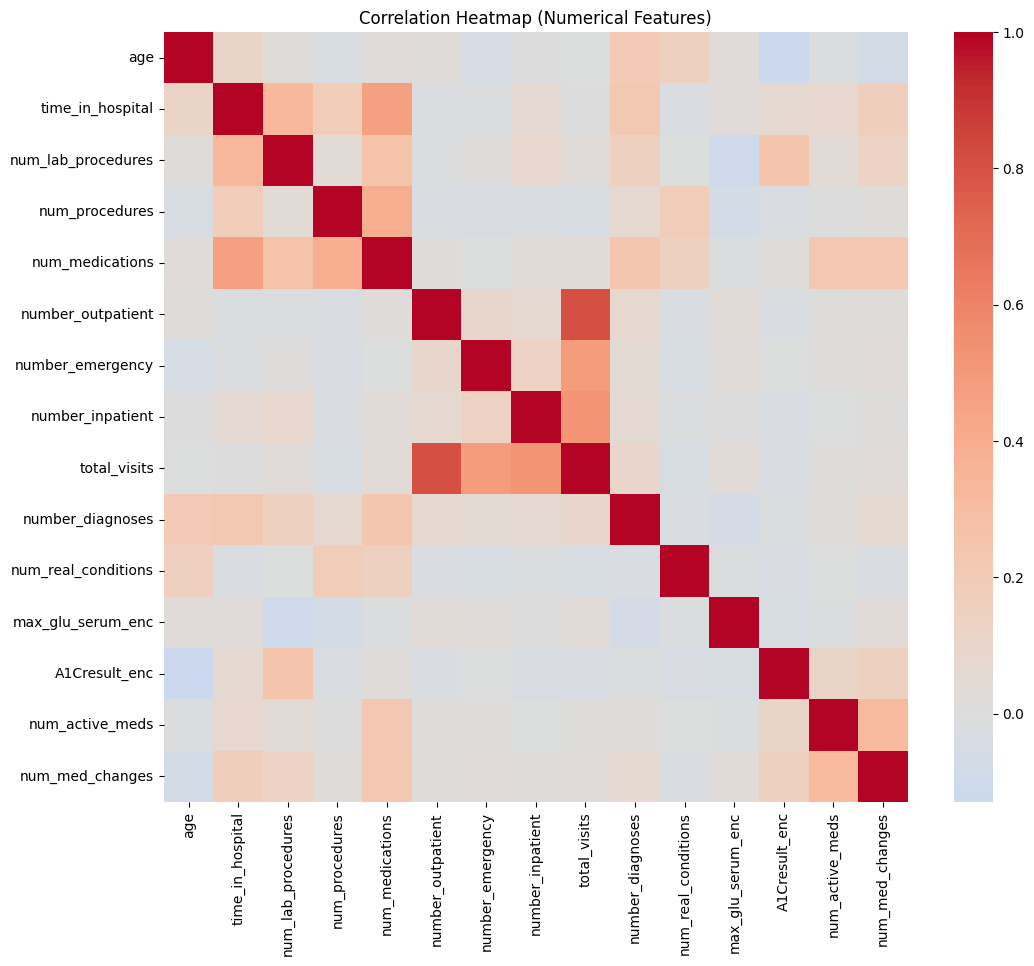

In [218]:
numeric_cols = [
    'age',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'total_visits',
    'number_diagnoses',
    'num_real_conditions',
    'max_glu_serum_enc',
    'A1Cresult_enc',
    'num_active_meds',
    'num_med_changes'
]

import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

The correlation heat map showed a moderate correlation between each healthcare usage metric and its individual components which means that the features are redundant. We also found correlations among the medication related variables and procedure related variables which seems to capture patient severity. However, most features were lowly correlated and appear to capture different information about the patient. These reasons justify the use of PCA to reduce the redundancy in these features and remove the informative ones.

# Data reduction and clustering:

The two different approaches to dimensionality reduction and clustering in order to compare results of both applied to the dataset.

- The first approach: the structured way. This consists in performing a dimensional reduction for the numerical variables using PCA and categorical variables using MCA, and concatenating these dimensions together with some of the raw variables, then performing clustering with K-Medoids on the Gower distance.

- The second approach: the unstructured way. This consists in performing a dimensional reduction for all the variables using PCA after the transformation and scaling, and performing clustering with K-Means on these dimensions.

Both approaches are applied to find the more appropriate one and compare the results obtained on the dataset.

## Approach 1: Data Reduction

For the preparation of dataset to be used for clustering dimensionality reduction techniques are implemented in order to handle the high dimensionality and redundancy of features. The dataset is composed of numerical, binary and categorical variables, many variables were considered redundant and/or described with high-dimensional one-hot encoding, which could harm distance based methods such as clustering with noise anddilution of valuable similarities.

Two complementary methods were used to perform dimensionality reduction: PCA and MCA. PCA was implemented on a subset of the numerical features related to hospitalization, i.e., the duration of the hospital stay, the number of visits or procedures since correlation studies showed moderately strong correlations between the latter. This method aims at projecting related variables on a lower number of continuous features retaining most of the variance.

MCA was implemented on high-dimensional categorical features, mainly administrative ones (i.e. Admission status, race, admission source and outcome status, described as multiple binary variables) in order to capture the correlations among these variables into a lower number of features.

The very clinically relevant and predictable features (e.g. Diagnosis-indicators, lab test, drugs-related features) were kept aside from the reduction processes in order to keep the information meaningful.

In [219]:
#  Define column groups 

pca_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient', 'total_visits'
]

mca_cols = [
    # Race
    'race_African American', 'race_Caucasian', 'race_Other',
    # Admission type
    'adm_type_Elective', 'adm_type_Emergency', 'adm_type_Other', 'adm_type_Urgent',
    # Discharge
    'discharge_Emergency_Transfer', 'discharge_Home', 'discharge_Home_Health',
    'discharge_Hospital_Transfer', 'discharge_Other', 'discharge_Other_Care',
    'discharge_Other_Facility', 'discharge_Rehab_Facility', 'discharge_Short_Hospital',
    'discharge_Skilled_Nursing', 'discharge_Transfer_Other',
    # Admission source
    'source_Clinic_Referral', 'source_Clinic_Referral_Transfer', 'source_Emergency_Room',
    'source_Health_Facility_Transfer', 'source_Hospital_Transfer', 'source_Other',
    'source_Physician_Referral', 'source_Transfer_SNF'
]

keep_raw_cols = [
    # Demographics
    'age', 'gender',
    # Diagnosis complexity
    'number_diagnoses', 'num_real_conditions',
    # Diagnosis flags
    'has_circulatory', 'has_diabetes', 'has_respiratory', 'has_neoplasms',
    'has_injury', 'has_genitourinary', 'has_musculoskeletal', 'has_digestive', 'has_other',
    # Lab results
    'max_glu_serum_enc', 'A1Cresult_enc',
    # Medication signals
    'diabetesMed', 'change', 'num_active_meds', 'num_med_changes',
    'insulin_active', 'insulin_increase', 'insulin_decrease',
    'metformin_active', 'metformin_increase', 'metformin_decrease'
]

target_cols = ['readmitted_binary', 'readmitted_early']

# Verify all columns are accounted for
all_assigned = set(pca_cols + mca_cols + keep_raw_cols + target_cols)
all_columns = set(df.columns)

missing = all_columns - all_assigned
extra = all_assigned - all_columns

print(f"PCA columns: {len(pca_cols)}")
print(f"MCA columns: {len(mca_cols)}")
print(f"Raw columns: {len(keep_raw_cols)}")
print(f"Target columns: {len(target_cols)}")
print(f"Total assigned: {len(all_assigned)}")
print(f"Total in df: {len(all_columns)}")
print(f"\nUnassigned columns: {missing}")
print(f"Assigned but not in df: {extra}")

PCA columns: 8
MCA columns: 26
Raw columns: 25
Target columns: 2
Total assigned: 61
Total in df: 61

Unassigned columns: set()
Assigned but not in df: set()


PCA columns: 8
MCA columns: 26
Raw columns: 25
Target columns: 2

Unassigned columns: set()
Assigned but not in df: set()

PCA section


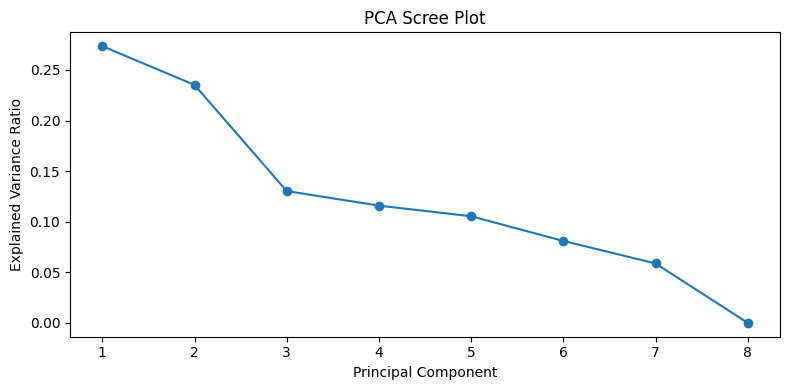

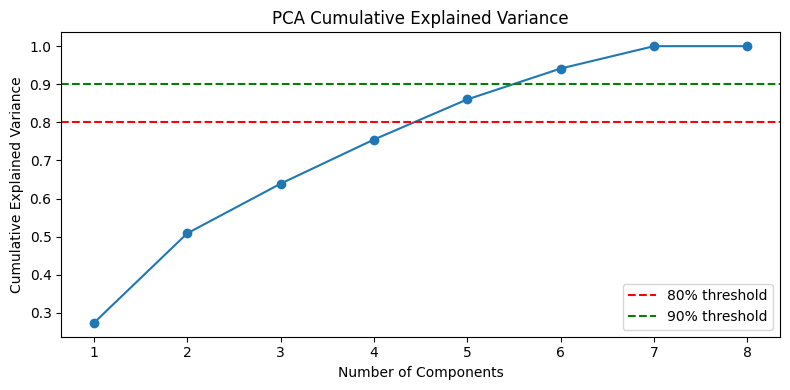


Explained variance per PCA component:
PC1: 0.273 (0.273 cumulative)
PC2: 0.235 (0.509 cumulative)
PC3: 0.130 (0.639 cumulative)
PC4: 0.116 (0.755 cumulative)
PC5: 0.105 (0.860 cumulative)
PC6: 0.081 (0.941 cumulative)
PC7: 0.059 (1.000 cumulative)
PC8: 0.000 (1.000 cumulative)

Keeping 5 PCA components (>= 80% variance)

PCA output shape: (67112, 5)
      pca_1     pca_2     pca_3     pca_4     pca_5
0 -0.525785 -0.038116 -0.715553 -0.608370 -0.289074
1  2.132470 -0.662302  2.293735  0.967108  1.645553
2 -0.632103 -0.436618 -0.007930 -0.063976 -0.067928
3 -0.698157 -1.287925 -0.617948 -0.450182 -0.159577
4 -0.691537  0.656028  1.837017  1.280675  0.372612

PCA Loadings:
                       pca_1     pca_2     pca_3     pca_4     pca_5
time_in_hospital    0.065125  0.552498 -0.173002 -0.145980 -0.056710
num_lab_procedures  0.078027  0.400458 -0.502482 -0.377006 -0.169393
num_procedures     -0.010816  0.410511  0.555027  0.404426  0.123035
num_medications     0.080011  0.589802  0.18

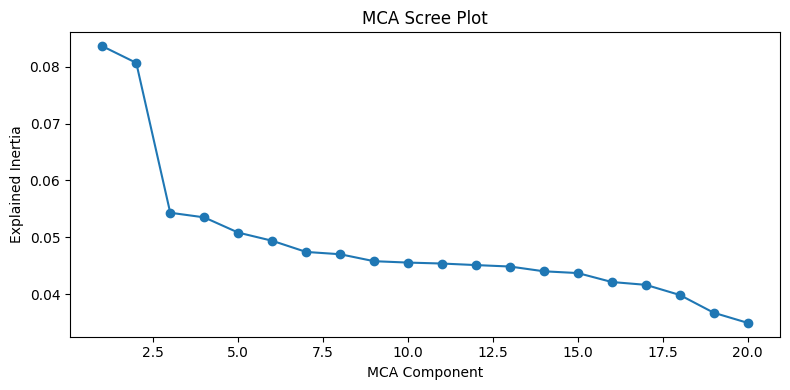

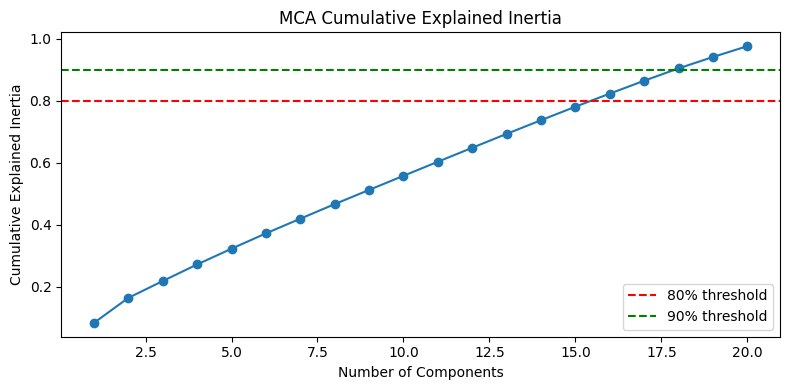


Explained inertia per MCA component:
MC1: 0.084 (0.084 cumulative)
MC2: 0.081 (0.164 cumulative)
MC3: 0.054 (0.219 cumulative)
MC4: 0.054 (0.272 cumulative)
MC5: 0.051 (0.323 cumulative)
MC6: 0.049 (0.372 cumulative)
MC7: 0.047 (0.420 cumulative)
MC8: 0.047 (0.467 cumulative)
MC9: 0.046 (0.513 cumulative)
MC10: 0.046 (0.558 cumulative)
MC11: 0.045 (0.603 cumulative)
MC12: 0.045 (0.649 cumulative)
MC13: 0.045 (0.693 cumulative)
MC14: 0.044 (0.737 cumulative)
MC15: 0.044 (0.781 cumulative)
MC16: 0.042 (0.823 cumulative)
MC17: 0.042 (0.865 cumulative)
MC18: 0.040 (0.905 cumulative)
MC19: 0.037 (0.941 cumulative)
MC20: 0.035 (0.976 cumulative)

70% threshold reached at 14 components
Keeping 14 MCA components

MCA output shape: (67112, 14)
      mca_1     mca_2     mca_3     mca_4     mca_5     mca_6     mca_7  \
0 -0.564317  0.152784 -0.157045 -0.103243 -0.201692 -0.058699 -0.081271   
1 -0.778990  0.120791 -0.317178 -0.291973  0.267695  0.320430  0.356947   
2 -0.564317  0.152784 -0.1570

In [220]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import prince

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# checking the column groups first
print("PCA columns:", len(pca_cols))
print("MCA columns:", len(mca_cols))
print("Raw columns:", len(keep_raw_cols))
print("Target columns:", len(target_cols))

all_assigned = set(pca_cols + mca_cols + keep_raw_cols + target_cols)
all_columns = set(df.columns)

missing = all_columns - all_assigned
extra = all_assigned - all_columns

print("\nUnassigned columns:", missing)
print("Assigned but not in df:", extra)

if len(missing) > 0:
    print("\nWarning: some columns are not assigned.")
if len(extra) > 0:
    print("\nWarning: some assigned columns are not in df.")


# PCA on numerical columns
print("\nPCA section")

# scale the numerical columns before PCA
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(df[pca_cols])

# fit PCA first using all components
pca_full = PCA()
pca_full.fit(X_pca_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

# scree plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.tight_layout()
plt.show()

# cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker='o')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
plt.axhline(y=0.90, color='green', linestyle='--', label='90% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

print("\nExplained variance per PCA component:")
for i, var in enumerate(explained_var):
    print(f"PC{i+1}: {var:.3f} ({cum_explained_var[i]:.3f} cumulative)")

# keep enough components to explain at least 80% variance
n_pca_components = np.argmax(cum_explained_var >= 0.80) + 1
print(f"\nKeeping {n_pca_components} PCA components (>= 80% variance)")

# fit PCA again with selected number of components
pca_final = PCA(n_components=n_pca_components, random_state=42)
X_pca_final = pca_final.fit_transform(X_pca_scaled)

pca_df = pd.DataFrame(
    X_pca_final,
    columns=[f"pca_{i+1}" for i in range(n_pca_components)],
    index=df.index
)

print("\nPCA output shape:", pca_df.shape)
print(pca_df.head())

# PCA loadings
pca_loadings = pd.DataFrame(
    pca_final.components_.T,
    index=pca_cols,
    columns=[f"pca_{i+1}" for i in range(n_pca_components)]
)

print("\nPCA Loadings:")
print(pca_loadings)


# MCA on one-hot encoded columns

print("\nMCA section")

X_mca = df[mca_cols].copy()

print("Any missing in MCA input?", X_mca.isnull().sum().sum())
print("MCA input dtypes:")
print(X_mca.dtypes.value_counts())

# fitting MCA first to inspect explained inertia
# columns are already one-hot encoded, so one_hot=False
mca_full = prince.MCA(
    n_components=min(len(mca_cols), 20),
    n_iter=10,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=42,
    one_hot=False
)

mca_full = mca_full.fit(X_mca)

# prince gives percentage_of_variance_ in percentages
mca_inertia = np.array(mca_full.percentage_of_variance_) / 100.0
cum_mca_inertia = np.cumsum(mca_inertia)

# scree-style plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(mca_inertia) + 1), mca_inertia, marker='o')
plt.xlabel("MCA Component")
plt.ylabel("Explained Inertia")
plt.title("MCA Scree Plot")
plt.tight_layout()
plt.show()

# cumulative inertia plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_mca_inertia) + 1), cum_mca_inertia, marker='o')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
plt.axhline(y=0.90, color='green', linestyle='--', label='90% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Inertia")
plt.title("MCA Cumulative Explained Inertia")
plt.legend()
plt.tight_layout()
plt.show()

print("\nExplained inertia per MCA component:")
for i, inertia in enumerate(mca_inertia):
    print(f"MC{i+1}: {inertia:.3f} ({cum_mca_inertia[i]:.3f} cumulative)")


# choose number of MCA components
mca_threshold = 0.70

if np.any(cum_mca_inertia >= mca_threshold):
    n_mca_components = np.argmax(cum_mca_inertia >= mca_threshold) + 1
    print(f"\n{mca_threshold*100:.0f}% threshold reached at {n_mca_components} components")
else:
    print(f"\n{mca_threshold*100:.0f}% threshold not reached — using 10 instead")
    n_mca_components = 10

print(f"Keeping {n_mca_components} MCA components")

# fit final MCA
mca_final = prince.MCA(
    n_components=n_mca_components,
    n_iter=10,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=42,
    one_hot=False
)

mca_fit = mca_final.fit(X_mca)
X_mca_final = mca_fit.transform(X_mca)

mca_df = pd.DataFrame(
    X_mca_final.to_numpy(),
    columns=[f"mca_{i+1}" for i in range(n_mca_components)],
    index=df.index
)

print("\nMCA output shape:", mca_df.shape)
print(mca_df.head())

print("\nMissing values in MCA components:")
print(mca_df.isnull().sum())


# creating the final reduced dataset
print("\nFinal reduced dataset")

df_reduced = pd.concat(
    [
        df[keep_raw_cols],
        pca_df,
        mca_df,
        df[target_cols]
    ],
    axis=1
)

print("Final reduced dataset shape:", df_reduced.shape)
print("\nColumns:")
print(df_reduced.columns.tolist())

print("\nFirst 5 rows:")
print(df_reduced.head())

print("\nMissing values in final reduced dataset:")
print(df_reduced.isnull().sum().sort_values(ascending=False).head(20))


# optional: save the reduced dataset
# df_reduced.to_csv("diabetes_reduced_dataset.csv", index=False)
# print("\nReduced dataset saved as diabetes_reduced_dataset.csv")

The PCA for numerical variables results in the effective reduction of information contained in them. Two principal components could account for 50.9% of the variance and five explain 86.0% of variance. Given that 80% of variance explained is considered good this suggests we do not lose much useful information with a reduced set of numerical features.

MCA results in less rapid accumulation of inertia explained, which is expected from one hot encoded features. 14 MCA components were needed to reach 70% of explained inertia, so categorical information appears more spread out across the feature space.

Finally, after combining chosen original raw features,pca features and mca features, and target variable, there is 67,112 observations and 46 features remaining in the reduced data set. There are only few missing values in variables apart from 'readmitted_early', which is obvious as this variable is available only for readmitted patients.

## Approach 1: Clustering:

This section involves the application of clustering on the dataset reduced above so as to identify clusters of patients with similar clinical as well as hospital characteristics. The target variables were dropped and only the feature variables were fed as clustering input. Given that the dataset is a mix of variables, the similarity measurement between observations has been carried out using Gower distance and the chosen clustering technique is K-Medoids.

The size of the dataset being relatively large, different values of k chosen initially using elbow method and silhouette score with a sample of the data to find the appropriate number of clusters and after selecting the correct value, the whole dataset was assigned labels according to cluster groups and then these cluster groups were interpreted using clinical variables and readmission data.

Clustering input shape: (67112, 44)
Missing values in clustering input:
age                   0
gender                0
metformin_decrease    0
pca_1                 0
pca_2                 0
pca_3                 0
pca_4                 0
pca_5                 0
mca_1                 0
mca_2                 0
dtype: int64

Sample shape: (5000, 44)

Computing Gower distance matrix...
Gower distance matrix shape: (5000, 5000)

Evaluating different k values:
k=2: inertia=615.0066, silhouette=0.1339
k=3: inertia=573.8384, silhouette=0.1448
k=4: inertia=546.9264, silhouette=0.1197
k=5: inertia=516.4034, silhouette=0.1044
k=6: inertia=508.8256, silhouette=0.0939
k=7: inertia=490.4833, silhouette=0.0942
k=8: inertia=470.1791, silhouette=0.0965


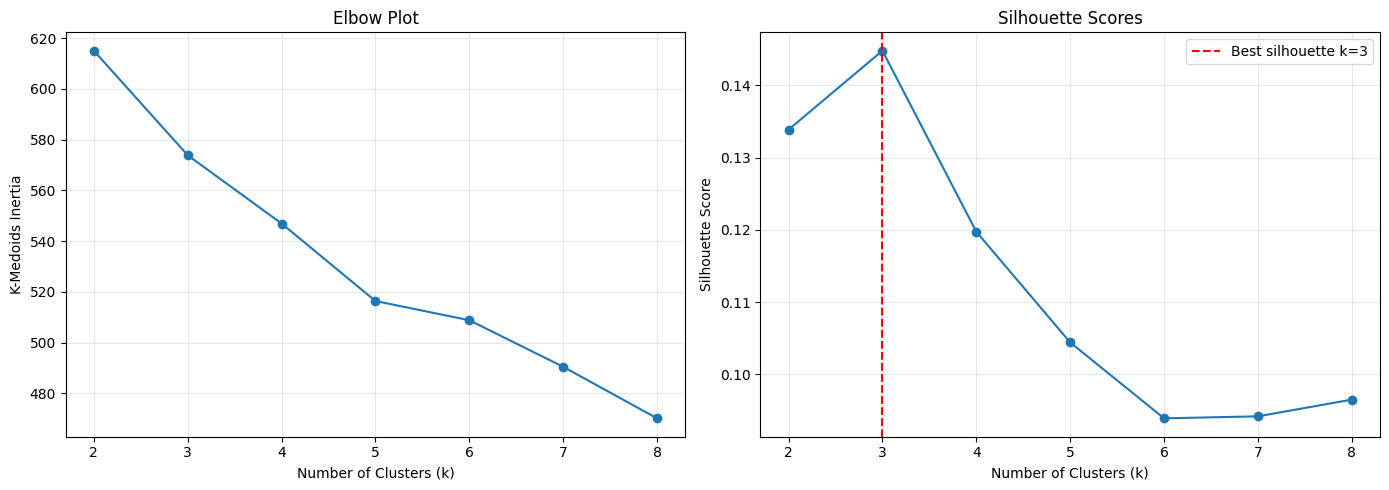


Silhouette would choose k = 3
Using k = 3 based on interpretability and cluster usefulness
Silhouette score for k = 3: 0.1448

Sample cluster sizes:
0     713
1    2324
2    1963
Name: count, dtype: int64

Assigning cluster labels to the full dataset...

Full dataset cluster sizes:
cluster
0    11155
1    34735
2    21222
Name: count, dtype: int64

Sample cluster distribution (%):
0    14.3
1    46.5
2    39.3
Name: count, dtype: float64

Full dataset cluster distribution (%):
cluster
0    16.6
1    51.8
2    31.6
Name: count, dtype: float64

Cluster profile means:
            age  number_diagnoses  num_real_conditions  max_glu_serum_enc  \
cluster                                                                     
0        62.450             6.361                2.722              0.052   
1        67.737             7.353                2.185              0.087   
2        64.334             7.787                2.186              0.091   

         A1Cresult_enc  num_active_meds  

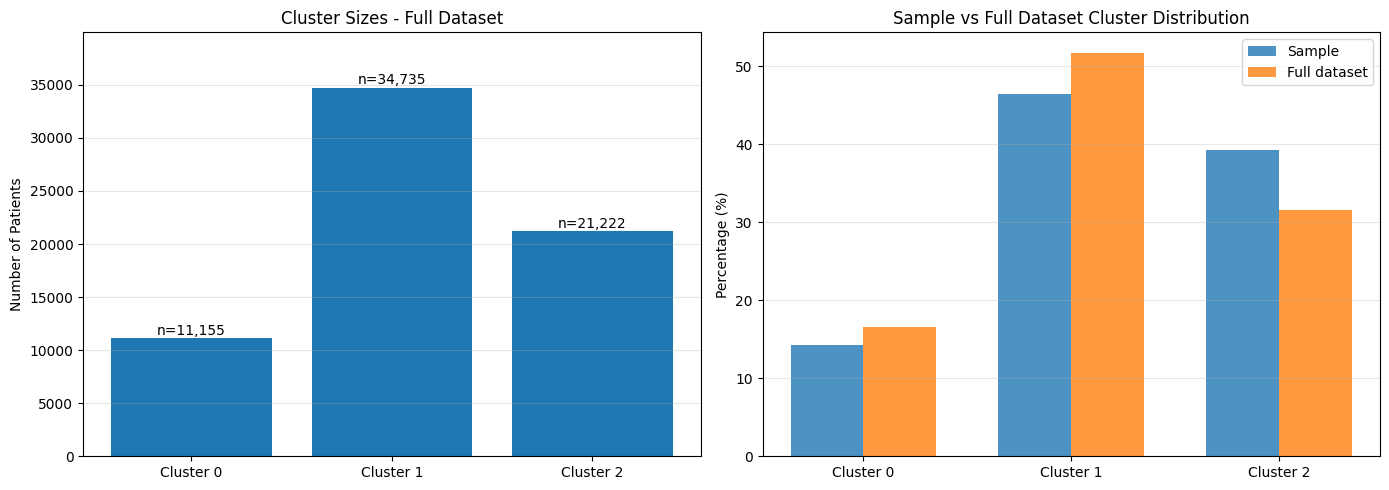

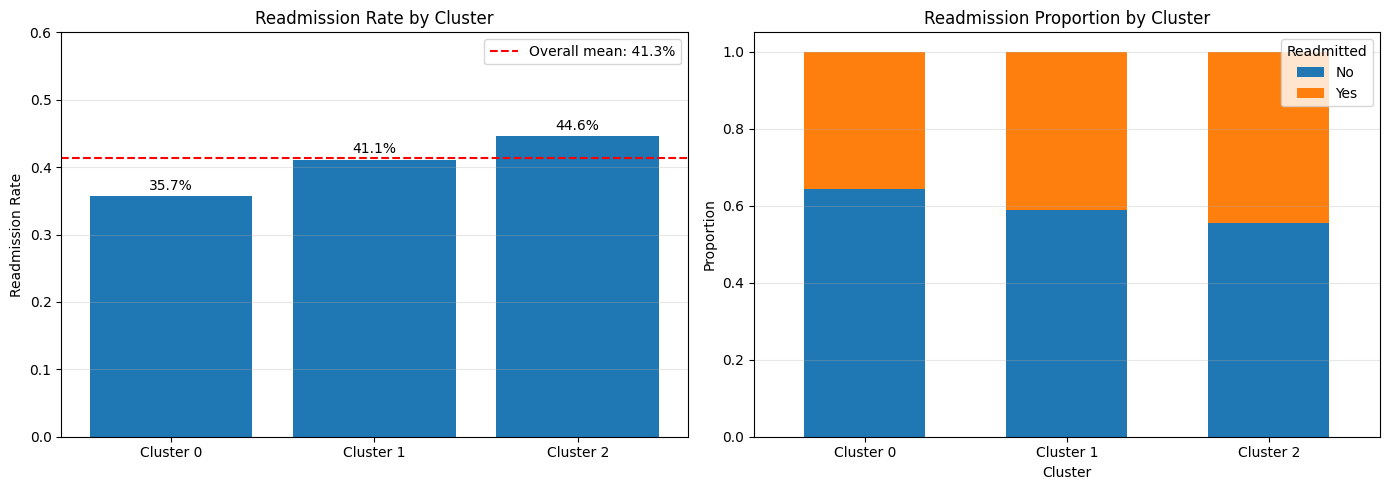

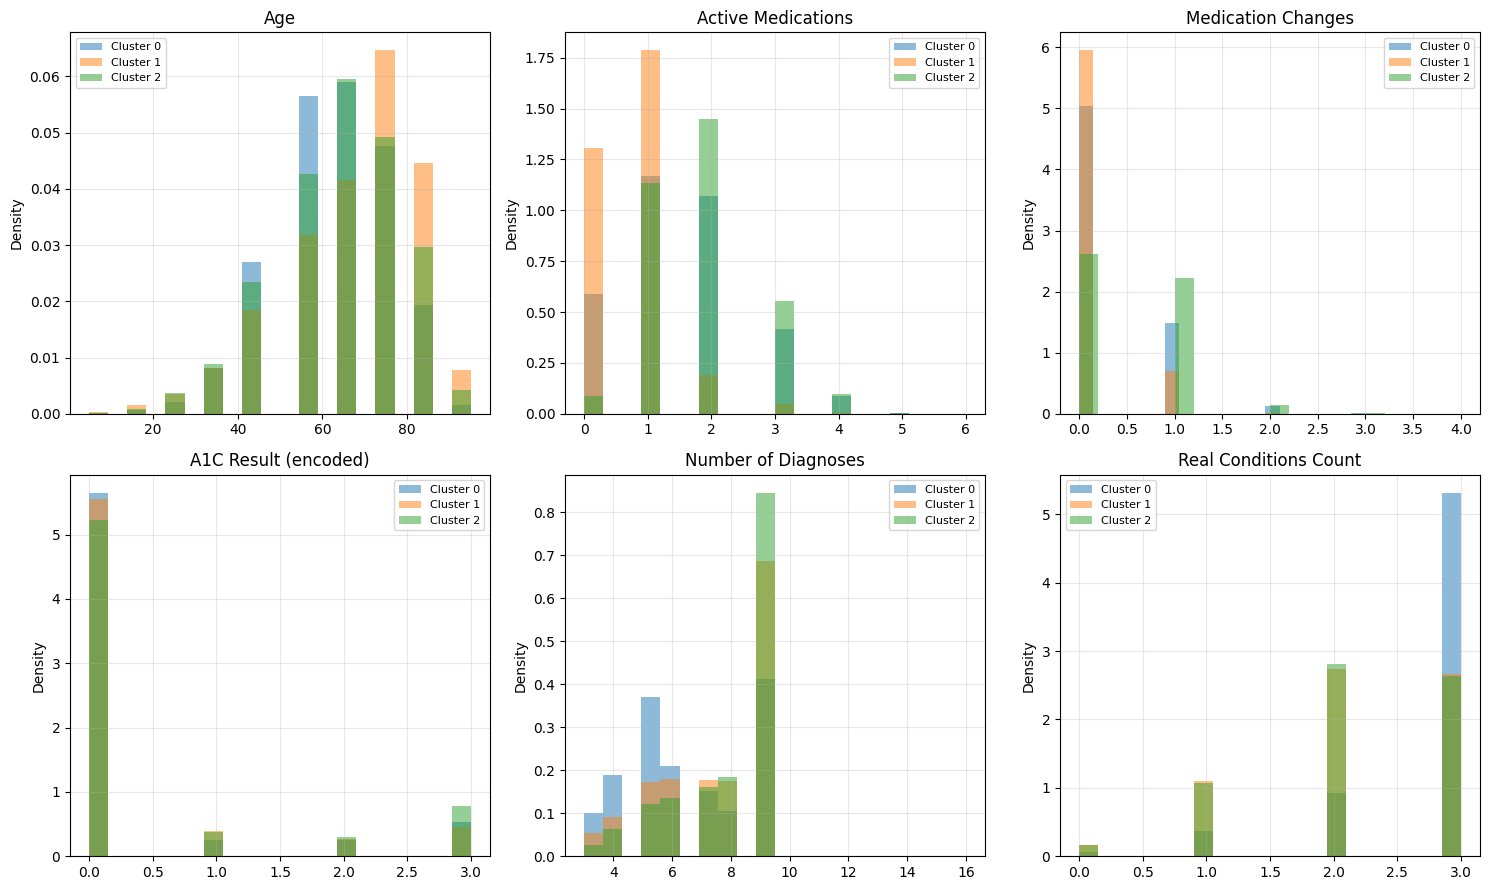

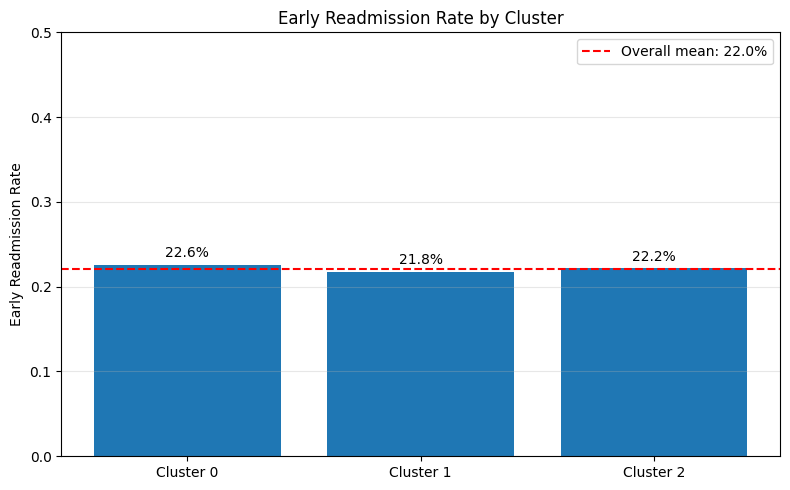


Early readmission rate by cluster:
cluster
0    0.226
1    0.218
2    0.222
Name: readmitted_early, dtype: float64

Clustering summary
Method: K-Medoids with Gower distance
Chosen k: 3
Best silhouette observed in search: 0.1448

Full dataset cluster sizes:
cluster
0    11155
1    34735
2    21222
Name: count, dtype: int64

Readmission rate by cluster:
cluster
0    0.357
1    0.411
2    0.446
Name: readmitted_binary, dtype: float64

Early readmission rate by cluster (readmitted patients only):
cluster
0    0.226
1    0.218
2    0.222
Name: readmitted_early, dtype: float64

Final clustered dataset shape: (67112, 47)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gower

from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.preprocessing import StandardScaler


# clustering input: use all features except the target variables
X_cluster = df_reduced.drop(columns=['readmitted_binary', 'readmitted_early']).copy()

print("Clustering input shape:", X_cluster.shape)
print("Missing values in clustering input:")
print(X_cluster.isnull().sum().sort_values(ascending=False).head(10))


# take a sample first because Gower distance is expensive on the full dataset
sample_size = 5000
random_state = 42

np.random.seed(random_state)
sample_idx = np.random.choice(X_cluster.index, size=sample_size, replace=False)

X_sample = X_cluster.loc[sample_idx].copy().reset_index(drop=True)
sample_full = df_reduced.loc[sample_idx].copy().reset_index(drop=True)

print("\nSample shape:", X_sample.shape)


# compute Gower distance on the sample
print("\nComputing Gower distance matrix...")
gower_dist_sample = gower.gower_matrix(X_sample)
print("Gower distance matrix shape:", gower_dist_sample.shape)


# test different values of k
k_range = range(2, 9)
inertias = []
sil_scores = []

print("\nEvaluating different k values:")
for k in k_range:
    model = KMedoids(
        n_clusters=k,
        metric='precomputed',
        init='k-medoids++',
        random_state=random_state
    )
    labels = model.fit_predict(gower_dist_sample)
    inertias.append(model.inertia_)
    sil = silhouette_score(gower_dist_sample, labels, metric='precomputed')
    sil_scores.append(sil)
    print(f"k={k}: inertia={model.inertia_:.4f}, silhouette={sil:.4f}")


# elbow plot and silhouette plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("K-Medoids Inertia")
axes[0].set_title("Elbow Plot")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, marker='o')
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Scores")
axes[1].axvline(
    x=list(k_range)[np.argmax(sil_scores)],
    color='red',
    linestyle='--',
    label=f'Best silhouette k={list(k_range)[np.argmax(sil_scores)]}'
)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# choose k
k_choice = 3

if k_choice == 'auto':
    best_k = list(k_range)[np.argmax(sil_scores)]
    print(f"\nAutomatically selected k = {best_k}")
else:
    best_k = k_choice
    auto_k = list(k_range)[np.argmax(sil_scores)]
    print(f"\nSilhouette would choose k = {auto_k}")
    print(f"Using k = {best_k} based on interpretability and cluster usefulness")
    print(f"Silhouette score for k = {best_k}: {sil_scores[best_k - list(k_range)[0]]:.4f}")


# fit final clustering model on the sample
final_model = KMedoids(
    n_clusters=best_k,
    metric='precomputed',
    init='k-medoids++',
    random_state=random_state
)

sample_labels = final_model.fit_predict(gower_dist_sample)
sample_full['cluster'] = sample_labels

print("\nSample cluster sizes:")
sample_cluster_counts = pd.Series(sample_labels).value_counts().sort_index()
print(sample_cluster_counts)


# assign cluster labels to the full dataset using distances to the medoids
continuous_cols = [
    'age', 'number_diagnoses', 'num_real_conditions',
    'max_glu_serum_enc', 'A1Cresult_enc',
    'num_active_meds', 'num_med_changes'
]

pca_component_cols = [col for col in X_cluster.columns if col.startswith('pca_')]
mca_component_cols = [col for col in X_cluster.columns if col.startswith('mca_')]

scale_cols = [col for col in (continuous_cols + pca_component_cols + mca_component_cols)
              if col in X_cluster.columns]

scaler = StandardScaler()

X_cluster_scaled = X_cluster.copy()
X_cluster_scaled[scale_cols] = scaler.fit_transform(X_cluster_scaled[scale_cols])

X_sample_scaled = X_sample.copy()
X_sample_scaled[scale_cols] = scaler.transform(X_sample_scaled[scale_cols])

medoid_vectors = X_sample_scaled.iloc[final_model.medoid_indices_].values

print("\nAssigning cluster labels to the full dataset...")
full_dist = pairwise_distances(
    X_cluster_scaled.values,
    medoid_vectors,
    metric='manhattan'
)

full_labels = np.argmin(full_dist, axis=1)

df_clustered = df_reduced.copy()
df_clustered['cluster'] = full_labels

print("\nFull dataset cluster sizes:")
full_cluster_counts = df_clustered['cluster'].value_counts().sort_index()
print(full_cluster_counts)

print("\nSample cluster distribution (%):")
print((sample_cluster_counts / sample_cluster_counts.sum() * 100).round(1))

print("\nFull dataset cluster distribution (%):")
print((full_cluster_counts / full_cluster_counts.sum() * 100).round(1))


# cluster profiling
profile_cols = [
    'age', 'number_diagnoses', 'num_real_conditions',
    'max_glu_serum_enc', 'A1Cresult_enc',
    'num_active_meds', 'num_med_changes', 'readmitted_binary'
]
profile_cols = [col for col in profile_cols if col in df_clustered.columns]

print("\nCluster profile means:")
print(df_clustered.groupby('cluster')[profile_cols].mean().round(3))

print("\nReadmission rate by cluster:")
print(df_clustered.groupby('cluster')['readmitted_binary'].mean().round(3))


# cluster sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    [f'Cluster {i}' for i in full_cluster_counts.index],
    full_cluster_counts.values
)
for i, val in enumerate(full_cluster_counts.values):
    axes[0].text(i, val + 300, f'n={val:,}', ha='center')
axes[0].set_title("Cluster Sizes - Full Dataset")
axes[0].set_ylabel("Number of Patients")
axes[0].set_ylim(0, max(full_cluster_counts.values) * 1.15)
axes[0].grid(True, alpha=0.3, axis='y')

x = np.arange(best_k)
width = 0.35
sample_pct = (sample_cluster_counts / sample_cluster_counts.sum() * 100).values
full_pct = (full_cluster_counts / full_cluster_counts.sum() * 100).values

axes[1].bar(x - width / 2, sample_pct, width, label='Sample', alpha=0.8)
axes[1].bar(x + width / 2, full_pct, width, label='Full dataset', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Cluster {i}' for i in range(best_k)])
axes[1].set_title("Sample vs Full Dataset Cluster Distribution")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


#  readmission by cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

readm_rate = df_clustered.groupby('cluster')['readmitted_binary'].mean()
bars = axes[0].bar([f'Cluster {i}' for i in readm_rate.index], readm_rate.values)

for bar, val in zip(bars, readm_rate.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.1%}',
        ha='center',
        va='bottom'
    )

axes[0].set_title("Readmission Rate by Cluster")
axes[0].set_ylabel("Readmission Rate")
axes[0].set_ylim(0, 0.6)
axes[0].axhline(
    y=df_clustered['readmitted_binary'].mean(),
    color='red',
    linestyle='--',
    label=f'Overall mean: {df_clustered["readmitted_binary"].mean():.1%}'
)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

cluster_prop = pd.crosstab(
    df_clustered['cluster'],
    df_clustered['readmitted_binary'],
    normalize='index'
)

cluster_prop.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    width=0.6
)
axes[1].set_title("Readmission Proportion by Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Proportion")
axes[1].set_xticklabels([f'Cluster {i}' for i in range(best_k)], rotation=0)
axes[1].legend(title='Readmitted', labels=['No', 'Yes'])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


#  feature distributions by cluster
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

features = [
    ('age', 'Age'),
    ('num_active_meds', 'Active Medications'),
    ('num_med_changes', 'Medication Changes'),
    ('A1Cresult_enc', 'A1C Result (encoded)'),
    ('number_diagnoses', 'Number of Diagnoses'),
    ('num_real_conditions', 'Real Conditions Count')
]

for ax, (col, title) in zip(axes.flatten(), features):
    for cluster in range(best_k):
        mask = df_clustered['cluster'] == cluster
        ax.hist(
            df_clustered.loc[mask, col],
            bins=20,
            alpha=0.5,
            label=f'Cluster {cluster}',
            density=True
        )
    ax.set_title(title)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#  early readmission among readmitted patients only
stage2 = df_clustered[df_clustered['readmitted_binary'] == 1].copy()
early_rate = stage2.groupby('cluster')['readmitted_early'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([f'Cluster {i}' for i in early_rate.index], early_rate.values)

for bar, val in zip(bars, early_rate.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.1%}',
        ha='center',
        va='bottom'
    )

ax.set_title("Early Readmission Rate by Cluster")
ax.set_ylabel("Early Readmission Rate")
ax.set_ylim(0, 0.5)
ax.axhline(
    y=stage2['readmitted_early'].mean(),
    color='red',
    linestyle='--',
    label=f'Overall mean: {stage2["readmitted_early"].mean():.1%}'
)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nEarly readmission rate by cluster:")
print(early_rate.round(3))


# final summary
print("\nClustering summary")
print(f"Method: K-Medoids with Gower distance")
print(f"Chosen k: {best_k}")
print(f"Best silhouette observed in search: {max(sil_scores):.4f}")
print("\nFull dataset cluster sizes:")
print(full_cluster_counts)
print("\nReadmission rate by cluster:")
print(df_clustered.groupby('cluster')['readmitted_binary'].mean().round(3))
print("\nEarly readmission rate by cluster (readmitted patients only):")
print(early_rate.round(3))
print(f"\nFinal clustered dataset shape: {df_clustered.shape}")

What we did in this part

The clustered input variables which excluded the target variables (to avoid leakage) were then passed through into the clustering stage. A sample of 5,000 observations was selected to compute Gower distance efficiently and K-Medoids clustering was applied for different numbers of cluster, and the optimal number of clusters, k, was decided using silhouette score, elbow analysis and interpretability.

The trained cluster medoids from the sample were then applied to the whole dataset to assign cluster labels to each observation. The continuous variables as well as PCA/ MCA components were standardise and assigned to closest medoids using Manhattan distance in order to assign labels to whole dataset efficiently.

The clusters were then described by selected clinical variables and readmission rate/ early readmission rate.


Based on the values for both silhouette score and elbow method, k=3 seemed to be the most appropriate choice of number of clusters. The maximum value for silhouette score occurred at k=3 (0.1448) and thereafter the score was diminishing with the increase in k value. This would imply further segmentation did not make it better separated. Although the silhouette score value is quite small but this can be considered quite normal in complex healthcare data and mixed attribute type of data.

The distribution of clusters in the sample and full dataset were the same, so the sampling method did not have bias, and thus the clustering results can be trusted.

The three cluster can be clearly distinguished based on some clinical criteria. 

- The Cluster 0 would contain relatively young patients, who received low number of diagnoses and they have low rate of readmission. Hence they represent a low risk patient group. 
- Cluster 1 would contain a moderate patient, who is of moderate age and having moderate features, and the rate of readmission for this group is average. 
- Cluster 2 represents a higher risk patient group as they received high number of diagnoses, taking high number of medications, and have highest rate of readmission.



### Clusters signifance:
- Cluster 0: stable intermediate cluster
Characteristics: least number of readmission (35.7%), least number of diagnosis (6.36) and youngest (62.4 years).
Interpretation: these seem to represent relatively less complicated patients. The relatively lower number of diagnosis and medication can indicate less disease complexification, lower treatment need and hence lower readmission rate. The cluster is indeed the most stable one.

- Cluster 1: Fragile Elderly cluster
Characteristics: highest average age (67.7 years) but lower medication use (0.7) and moderate readmission rate (41.1%).
Interpretation: this cluster is of highest age, but is also characterized by low medication usage, the readmission rate being around the average one can argue age is part of the picture contributing to hospitalization regardless of the degree of treatment complexity.

- Cluster 2: unstable metabolic cluster
Characteristics: highest number of readmission (44.6%), highest number of diagnosis (7.78), highest number of medication (1.84), highest number of medication changes (0.51).
Interpretation: these patients are probably the more complicated one. Higher number of diagnosis implies higher disease burden, the high number of medication prescribed and modification suggest difficult disease management. This is consequently also indicated by the highest readmission rate.


The 3 clusters generated are meaningfully differentiating patients based on the complexity of their illness and readmission risk. Especially Cluster 2 could be identified as the group with the most complex and risky condition.

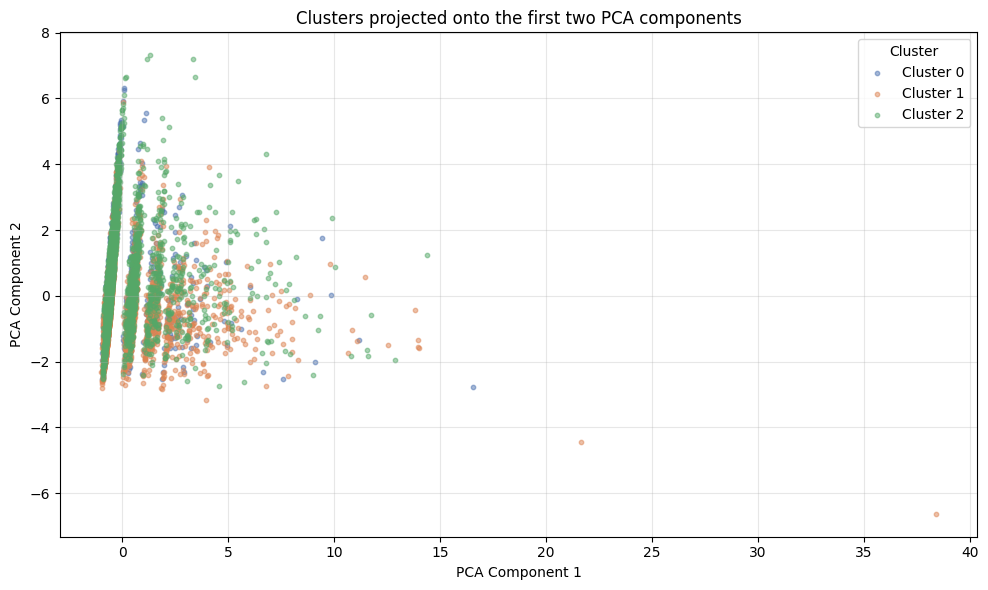

In [196]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# use the PCA components already created earlier
sample_size = min(8000, len(df_clustered))
random_state = 42

np.random.seed(random_state)
plot_idx = np.random.choice(df_clustered.index, size=sample_size, replace=False)

plot_df = df_clustered.loc[plot_idx, ['pca_1', 'pca_2', 'cluster']].copy()

fig, ax = plt.subplots(figsize=(10, 6))

colors = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868'}

for cluster in sorted(plot_df['cluster'].unique()):
    cluster_data = plot_df[plot_df['cluster'] == cluster]
    ax.scatter(
        cluster_data['pca_1'],
        cluster_data['pca_2'],
        color=colors.get(cluster, 'gray'),
        label=f'Cluster {cluster}',
        alpha=0.5,
        s=10
    )

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('Clusters projected onto the first two PCA components')
ax.legend(title='Cluster')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The 2-dimensional plot was produced using the first two PCA components so that the data could be visualized. The plot reveals a large degree of overlap between clusters and that they do not clearly separate into their own distinct regions.

This implies that in low dimensions clusters are not separable with great clarity, which would not be surprising given the complex dataset and use of various types of variable. It must be noted that clustering has been done using the Gower distance over a variety of different variable types and so the entire structure of the cluster cannot be interpreted visually over only 2 dimensions of PCA.

However, in spite of the visualization, earlier evidence showed there to be significant variation between clusters over clinical variables and readmission rates, so there still appears to be a cluster worth looking into.

## Approach 2: Data reduction 

Two different ways of reducing the dimension were tested: first one consisted of using PCA on numerical features and MCA on categorical features, while keeping some raw features. The second method consisted of using a PCA on all variables.

The first approach was more suitable for the problem because we have mixed type of features: PCA is suited for continuous features and MCA for categorical features. A mixed PCA + MCA will respect better the data structure than a PCA performed on all the variables together.

The second approach was used as a comparison approach: what happens if we apply only one PCA globally.

In [140]:
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# alternative data reduction approach:
# apply PCA to all feature variables and compare with the mixed PCA + MCA approach

feature_cols_approach1 = [
    col for col in df.columns
    if col not in ['readmitted_binary', 'readmitted_early', 'readmitted', 'patient_nbr']
]

X_approach1 = df[feature_cols_approach1].copy()

# scale all input features before PCA
scaler_approach1 = StandardScaler()
X_approach1_scaled = scaler_approach1.fit_transform(X_approach1)

print("Approach 1 input shape:", X_approach1_scaled.shape)

# fit PCA first using all components so the explained variance can be checked
pca_approach1_full = PCA(random_state=42)
pca_approach1_full.fit(X_approach1_scaled)

explained_var_a1 = pca_approach1_full.explained_variance_ratio_
cum_explained_var_a1 = np.cumsum(explained_var_a1)

# scree plot and cumulative explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 21), explained_var_a1[:20], marker='o')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("PCA Scree Plot")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, 21), cum_explained_var_a1[:20], marker='o')
axes[1].axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(y=0.90, color='green', linestyle='--', label='90% threshold')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nExplained variance per component (first 10):")
for i in range(min(10, len(explained_var_a1))):
    print(f"PC{i+1}: {explained_var_a1[i]:.3f} ({cum_explained_var_a1[i]:.3f} cumulative)")

# keep enough components to explain at least 80% of the variance
n_components_approach1 = np.argmax(cum_explained_var_a1 >= 0.80) + 1
print(f"\nKeeping {n_components_approach1} components (>= 80% variance)")

# fit final PCA with the selected number of components
pca_approach1_final = PCA(n_components=n_components_approach1, random_state=42)
X_approach1_reduced = pca_approach1_final.fit_transform(X_approach1_scaled)

df_approach1_reduced = pd.DataFrame(
    X_approach1_reduced,
    columns=[f'pca_all_{i+1}' for i in range(n_components_approach1)],
    index=df.index
)

# add the target variables back after reduction
df_approach1_reduced['readmitted_binary'] = df['readmitted_binary'].values
df_approach1_reduced['readmitted_early'] = df['readmitted_early'].values

print("\nApproach 1 reduced dataset shape:", df_approach1_reduced.shape)
print(df_approach1_reduced.head())
'''

'\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\nfrom sklearn.decomposition import PCA\nfrom sklearn.preprocessing import StandardScaler\n\n\n# alternative data reduction approach:\n# apply PCA to all feature variables and compare with the mixed PCA + MCA approach\n\nfeature_cols_approach1 = [\n    col for col in df.columns\n    if col not in [\'readmitted_binary\', \'readmitted_early\', \'readmitted\', \'patient_nbr\']\n]\n\nX_approach1 = df[feature_cols_approach1].copy()\n\n# scale all input features before PCA\nscaler_approach1 = StandardScaler()\nX_approach1_scaled = scaler_approach1.fit_transform(X_approach1)\n\nprint("Approach 1 input shape:", X_approach1_scaled.shape)\n\n# fit PCA first using all components so the explained variance can be checked\npca_approach1_full = PCA(random_state=42)\npca_approach1_full.fit(X_approach1_scaled)\n\nexplained_var_a1 = pca_approach1_full.explained_variance_ratio_\ncum_explained_var_a1 = np.cumsum(explained_var_a1)

Comparison of the two methods of reducing dimensions: The PCA-only method required 33 components to keep 80% of the variance. The PCA + MCA method, as established above, required considerably fewer dimensions. Similarly, the explained variance per dimension is much lower for the PCA-only method than that for PCA + MCA method; this also means that the information in the data is distributed over many more dimensions.

This indicates that applying PCA on all variables at once is not a good approach for this particular dataset. One-hot encoded categorical variables make it difficult for PCA to extract the strongest structure in data. PCA is best suited to continuous variables.

The approach PCA + MCA resulted in a more effective reduction of dimensions as it used different methods for different types of variables. This also result in a much more compact and interpretable representation of data: much better suited for clustering

## Approach 2: Clustering

Second Approach to Clustering

In this section, a second approach to clustering was tried using the PCA-only reduced data set that had been produced earlier in the section on PCA. This approach was used to compare against the primary method used, which had a combination of PCA+MCA reduction with a Gower distance and K-Medoids based clustering method.

For this analysis K-Means clustering was used with the PCA components and the removed target variables. Using values for k (using the elbow method and silhouette scores), k=3 was chosen to allow for a direct comparison with the primary approach.

When analysing the resulting clusters it was viewed in terms of number of members, readmission rate and visualization using the PCA results. These were then compared with the results from the main approach in an attempt to determine the most clinically appropriate and intuitive groupings of patients.

In [141]:
'''
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# second clustering approach:
# K-Means on the PCA-only reduced dataset
# this is used to compare against the main clustering approach

X_approach2_cluster = df_approach1_reduced.drop(
    columns=['readmitted_binary', 'readmitted_early']
).copy()

print("Approach 2 clustering input shape:", X_approach2_cluster.shape)


# try different k values
k_range = range(2, 9)
inertias_a2 = []
sil_scores_a2 = []

print("\nEvaluating k values for Approach 2:")
for k in k_range:
    model_a2 = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_a2 = model_a2.fit_predict(X_approach2_cluster)
    inertias_a2.append(model_a2.inertia_)
    sil = silhouette_score(X_approach2_cluster, labels_a2)
    sil_scores_a2.append(sil)
    print(f"k={k}: inertia={model_a2.inertia_:.2f}, silhouette={sil:.4f}")


# elbow plot and silhouette plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias_a2, marker='o')
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("K-Means Inertia")
axes[0].set_title("Elbow Plot")
axes[0].grid(True, alpha=0.3)

best_k_auto_a2 = list(k_range)[np.argmax(sil_scores_a2)]
axes[1].plot(list(k_range), sil_scores_a2, marker='o')
axes[1].axvline(x=best_k_auto_a2, color='red', linestyle='--', label=f'Best k={best_k_auto_a2}')
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Scores")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# choose final k
# set to 3 for direct comparison with the main approach
best_k_a2 = 3
print(f"\nUsing k = {best_k_a2} for comparison with the main clustering approach")

kmeans_approach2 = KMeans(n_clusters=best_k_a2, random_state=42, n_init=10)
labels_approach2 = kmeans_approach2.fit_predict(X_approach2_cluster)

df_approach1_reduced['cluster_approach2'] = labels_approach2

print("\nApproach 2 cluster sizes:")
cluster_sizes_a2 = pd.Series(labels_approach2).value_counts().sort_index()
print(cluster_sizes_a2)

print("\nApproach 2 readmission rate by cluster:")
readm_a2 = df_approach1_reduced.groupby('cluster_approach2')['readmitted_binary'].mean().round(3)
print(readm_a2)


# projection plot using first two PCA components
sample_size = min(8000, len(df_approach1_reduced))
np.random.seed(42)
plot_idx_a2 = np.random.choice(df_approach1_reduced.index, size=sample_size, replace=False)

plot_df_a2 = df_approach1_reduced.loc[
    plot_idx_a2,
    ['pca_all_1', 'pca_all_2', 'cluster_approach2']
].copy()

colors_a2 = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868'}

fig, ax = plt.subplots(figsize=(10, 6))

for cluster in sorted(plot_df_a2['cluster_approach2'].unique()):
    cluster_data = plot_df_a2[plot_df_a2['cluster_approach2'] == cluster]
    ax.scatter(
        cluster_data['pca_all_1'],
        cluster_data['pca_all_2'],
        color=colors_a2.get(cluster, 'gray'),
        label=f'Cluster {cluster}',
        alpha=0.5,
        s=10
    )

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("Approach 2: K-Means clusters on PCA-only reduced data")
ax.legend(title='Cluster')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# loadings for the first principal component
loadings_a2 = pd.Series(
    pca_approach1_final.components_[0],
    index=feature_cols_approach1
).sort_values()

print("\nTop 10 negative loadings on PCA component 1:")
print(loadings_a2.head(10).round(3))

print("\nTop 10 positive loadings on PCA component 1:")
print(loadings_a2.tail(10).round(3))


# compare readmission rates with the main approach
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(
    [f'Cluster {i}' for i in readm_a2.index],
    readm_a2.values,
    color=list(colors_a2.values())
)
for bar, val in zip(bars, readm_a2.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.1%}',
        ha='center',
        va='bottom'
    )
axes[0].set_title("Approach 2: PCA-only + K-Means\nReadmission Rate by Cluster")
axes[0].set_ylabel("Readmission Rate")
axes[0].set_ylim(0, 0.6)
axes[0].axhline(
    y=df_approach1_reduced['readmitted_binary'].mean(),
    color='red',
    linestyle='--',
    label=f'Overall: {df_approach1_reduced["readmitted_binary"].mean():.1%}'
)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# main approach from earlier
colors_main = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868'}
readm_main = df_clustered.groupby('cluster')['readmitted_binary'].mean()

bars = axes[1].bar(
    [f'Cluster {i}' for i in readm_main.index],
    readm_main.values,
    color=list(colors_main.values())
)
for bar, val in zip(bars, readm_main.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.1%}',
        ha='center',
        va='bottom'
    )
axes[1].set_title("Main approach: PCA + MCA + K-Medoids\nReadmission Rate by Cluster")
axes[1].set_ylabel("Readmission Rate")
axes[1].set_ylim(0, 0.6)
axes[1].axhline(
    y=df_clustered['readmitted_binary'].mean(),
    color='red',
    linestyle='--',
    label=f'Overall: {df_clustered["readmitted_binary"].mean():.1%}'
)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# compare cluster sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    [f'Cluster {i}' for i in cluster_sizes_a2.index],
    cluster_sizes_a2.values,
    color=list(colors_a2.values())
)
for i, val in enumerate(cluster_sizes_a2.values):
    axes[0].text(i, val + 300, f'n={val:,}', ha='center')
axes[0].set_title("Approach 2: PCA-only + K-Means\nCluster Sizes")
axes[0].set_ylabel("Number of Patients")
axes[0].set_ylim(0, max(cluster_sizes_a2.values) * 1.15)
axes[0].grid(True, alpha=0.3, axis='y')

cluster_sizes_main = df_clustered['cluster'].value_counts().sort_index()
axes[1].bar(
    [f'Cluster {i}' for i in cluster_sizes_main.index],
    cluster_sizes_main.values,
    color=list(colors_main.values())
)
for i, val in enumerate(cluster_sizes_main.values):
    axes[1].text(i, val + 300, f'n={val:,}', ha='center')
axes[1].set_title("Main approach: PCA + MCA + K-Medoids\nCluster Sizes")
axes[1].set_ylabel("Number of Patients")
axes[1].set_ylim(0, max(cluster_sizes_main.values) * 1.15)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# summary comparison
sil_a2_final = silhouette_score(X_approach2_cluster, labels_approach2)
sil_main = 0.1448  

print("\n" + "=" * 60)
print("CLUSTERING APPROACH COMPARISON")
print("=" * 60)
print(f"{'Metric':<35} {'Approach 2':>12} {'Main approach':>15}")
print("-" * 60)
print(f"{'Reduction Method':<35} {'PCA (all)':>12} {'PCA + MCA':>15}")
print(f"{'Clustering Method':<35} {'K-Means':>12} {'K-Medoids':>15}")
print(f"{'Distance Metric':<35} {'Euclidean':>12} {'Gower':>15}")
print(f"{'Silhouette Score':<35} {sil_a2_final:>12.4f} {sil_main:>15.4f}")
print(f"{'Handles mixed data correctly':<35} {'No':>12} {'Yes':>15}")
print(f"{'Cluster centres = real patients':<35} {'No':>12} {'Yes':>15}")
print(
    f"{'Readmission spread':<35} "
    f"{f'{readm_a2.max() - readm_a2.min():.1%}':>12} "
    f"{f'{readm_main.max() - readm_main.min():.1%}':>15}"
)
print("=" * 60)
'''

'\nfrom sklearn.cluster import KMeans\nfrom sklearn.metrics import silhouette_score\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\n\n\n# second clustering approach:\n# K-Means on the PCA-only reduced dataset\n# this is used to compare against the main clustering approach\n\nX_approach2_cluster = df_approach1_reduced.drop(\n    columns=[\'readmitted_binary\', \'readmitted_early\']\n).copy()\n\nprint("Approach 2 clustering input shape:", X_approach2_cluster.shape)\n\n\n# try different k values\nk_range = range(2, 9)\ninertias_a2 = []\nsil_scores_a2 = []\n\nprint("\nEvaluating k values for Approach 2:")\nfor k in k_range:\n    model_a2 = KMeans(n_clusters=k, random_state=42, n_init=10)\n    labels_a2 = model_a2.fit_predict(X_approach2_cluster)\n    inertias_a2.append(model_a2.inertia_)\n    sil = silhouette_score(X_approach2_cluster, labels_a2)\n    sil_scores_a2.append(sil)\n    print(f"k={k}: inertia={model_a2.inertia_:.2f}, silhouette={sil:.4f}")\n\n\n# elbo

Comparison between clustering methods

The PCA-only + K-Means produced less separated clusters (silhoulette score=0.0929) than the main PCA + MCA + K-Medoids method (silhoulette score=0.1448). It also resulted in more unbalanced clusters with one group containing more than half of the observations which suggest less efficient segmentation. Despite having certain distinction of readmission rates between groups, the overall structure of clusters were less distinct and interpretative. On the other hand, the main method generated better separated and balanced clusters; also appropriate to deal with mixed variable types by Gower distance and K-Medoids. Therefore, the main method was considered more effective.

It looks like the PCA only method has a higher visible separation between classes on the 2D scatter plot, but this is predictable because it uses the same PCA components for both clustering and visualisation.

With the main approach 1, higher dimensions of combined data types are used which cannot all be visually displayed in only 2 dimensions. Therefore the visualisation is less separate, although the clustering is more meaningful with a higher silhouette score.

## Validating clusters using the winner approach: approach 1

Examining clusters from appraoch 1:

The cluster assignments were viewed at the patient level in order to identify how observations are grouped. A subset of rows were displayed that show the assigned cluster membership along with some selected clinical factors: age, A1C reading, active number of medications, change in medication use, and admission for readmission.

This examination was conducted as a check that cluster assignments have indeed been added. It allows us to see representative patients that fall into each cluster.

In [142]:
# check how patients were assigned to clusters

cols_to_view = [
    'age', 'A1Cresult_enc', 'num_active_meds',
    'num_med_changes', 'readmitted_binary', 'cluster'
]

# first 10 patients
print("Cluster assignments for the first 10 patients:")
print(df_clustered[cols_to_view].head(10))


# check one specific patient by row index
row_idx = 5   

print(f"\nPatient at row {row_idx}:")
print(df_clustered.loc[row_idx, cols_to_view])


# check a few selected patients
rows_to_check = [0, 10, 100, 500, 1000]

print("\nSelected patients:")
print(df_clustered.loc[rows_to_check, cols_to_view])


# show a few example patients from one cluster
cluster_num = 2  

print(f"\nExample patients from Cluster {cluster_num}:")
print(
    df_clustered[df_clustered['cluster'] == cluster_num][cols_to_view]
    .head(10)
)


# number of patients in each cluster
print("\nNumber of patients in each cluster:")
print(df_clustered['cluster'].value_counts().sort_index())

Cluster assignments for the first 10 patients:
   age  A1Cresult_enc  num_active_meds  num_med_changes  readmitted_binary  \
0   15              0                1                1                  1   
1   25              0                1                0                  0   
2   35              0                1                1                  0   
3   45              0                2                0                  0   
4   55              0                1                0                  1   
5   65              0                3                0                  0   
6   75              0                1                0                  1   
7   85              0                2                0                  0   
8   95              0                2                0                  0   
9   45              0                1                0                  1   

   cluster  
0        2  
1        1  
2        1  
3        1  
4        0  
5        0  
6  


Some patients were selected to review if the cluster labels assigned to the patients are meaningful. It seems that the clustering results can successfully assign the patients into groups that contain patients with the same characteristics.

The example of Cluster 2 shows that more patients with a higher number of medications and changes of medications fall into Cluster 2 which is interpreted as the highest risk group earlier.

## Data ready for modelling:


In [167]:
from sklearn.model_selection import train_test_split
import pandas as pd
import pickle


# 1. build modelling inputs

raw_feature_cols = [
    col for col in df.columns
    if col not in ['readmitted_binary', 'readmitted_early']
]
X_full_raw = df[raw_feature_cols].copy()

y_stage1 = df['readmitted_binary'].copy()
y_stage2_full = df['readmitted_early'].copy()

print(f"Number of raw modelling features: {len(raw_feature_cols)}")


# 2. train/test split

X_train_raw, X_test_raw, y_train_s1, y_test_s1 = train_test_split(
    X_full_raw,
    y_stage1,
    test_size=0.2,
    random_state=42,
    stratify=y_stage1
)

print("\nTrain/test shapes:")
print("X_train_raw:", X_train_raw.shape)
print("X_test_raw: ", X_test_raw.shape)

print("\nStage 1 target distribution (train):")
print(y_train_s1.value_counts())

print("\nStage 1 target distribution (test):")
print(y_test_s1.value_counts())


# 3. build final modelling datasets
# Tree models: keep all features (multicollinearity doesn't matter)
# Logistic regression: fix multicollinearity issues

def drop_dummy_reference_categories(df):
    """
    Drop one dummy variable from each categorical group
    to avoid perfect multicollinearity in logistic regression.
    """
    df = df.copy()
    
    groups = {
        "race": [col for col in df.columns if col.startswith("race_")],
        "discharge": [col for col in df.columns if col.startswith("discharge_")],
        "adm_type": [col for col in df.columns if col.startswith("adm_type_")],
        "source": [col for col in df.columns if col.startswith("source_")],
    }
    
    dropped_cols = []
    
    for group_name, cols in groups.items():
        if len(cols) > 1:
            drop_col = cols[0]
            df = df.drop(columns=[drop_col])
            dropped_cols.append(drop_col)
    
    if dropped_cols:
        print(f"\nDropped {len(dropped_cols)} reference categories (dummy variable trap):")
        for col in dropped_cols:
            print(f"  - {col}")
    
    return df


def drop_redundant_features(df):
    """
    Drop redundant engineered features.
    If total_visits = number_outpatient + number_emergency + number_inpatient,
    keep total_visits and drop the individual components.
    """
    df = df.copy()
    
    visit_cols = ['number_outpatient', 'number_emergency', 'number_inpatient', 'total_visits']
    
    if all(col in df.columns for col in visit_cols):
        df = df.drop(columns=['number_outpatient', 'number_emergency', 'number_inpatient'])
        print("\nDropped redundant visit features (kept total_visits):")
        print("  - number_outpatient")
        print("  - number_emergency")
        print("  - number_inpatient")
    
    return df


# tree models - keep all features
X_train_model = X_train_raw.copy()
X_test_model = X_test_raw.copy()

# logistic regression - fix multicollinearity
print("\nPreparing logistic regression datasets:")
X_train_lr = drop_dummy_reference_categories(X_train_raw)
X_train_lr = drop_redundant_features(X_train_lr)
X_test_lr = X_test_lr[X_train_lr.columns]

print("\nFinal modelling dataset shapes:")
print("X_train_model:", X_train_model.shape, "- tree models (all features)")
print("X_test_model: ", X_test_model.shape)
print("X_train_lr:   ", X_train_lr.shape, "- logistic regression (multicollinearity fixed)")
print("X_test_lr:    ", X_test_lr.shape)


# 4. stage 2 data (readmitted patients only)

train_readmitted_mask = y_train_s1 == 1
test_readmitted_mask = y_test_s1 == 1

y_train_s2 = y_stage2_full.loc[y_train_s1[train_readmitted_mask].index].dropna().astype(int)
y_test_s2 = y_stage2_full.loc[y_test_s1[test_readmitted_mask].index].dropna().astype(int)

# tree models
X_train_s2 = X_train_model.loc[y_train_s2.index].copy()
X_test_s2 = X_test_model.loc[y_test_s2.index].copy()

# logistic regression
X_train_s2_lr = X_train_lr.loc[y_train_s2.index].copy()
X_test_s2_lr = X_test_lr.loc[y_test_s2.index].copy()


# 5. summary

print("\n" + "="*60)
print("DATASETS READY FOR MODELLING")
print("="*60)

print("\nStage 1 (all patients):")
print("X_train_model:", X_train_model.shape, "- tree models")
print("X_test_model: ", X_test_model.shape, "- tree models")
print("X_train_lr:   ", X_train_lr.shape, "- logistic regression")
print("X_test_lr:    ", X_test_lr.shape, "- logistic regression")

print("\nStage 2 (readmitted patients only):")
print("X_train_s2:   ", X_train_s2.shape, "- tree models")
print("X_test_s2:    ", X_test_s2.shape, "- tree models")
print("X_train_s2_lr:", X_train_s2_lr.shape, "- logistic regression")
print("X_test_s2_lr: ", X_test_s2_lr.shape, "- logistic regression")

print("\nTarget shapes:")
print("y_train_s1:", y_train_s1.shape)
print("y_test_s1: ", y_test_s1.shape)
print("y_train_s2:", y_train_s2.shape)
print("y_test_s2: ", y_test_s2.shape)

print("\nMissing values:")
print("X_train_model:", X_train_model.isnull().sum().sum())
print("X_test_model: ", X_test_model.isnull().sum().sum())
print("X_train_s2:   ", X_train_s2.isnull().sum().sum())
print("X_test_s2:    ", X_test_s2.isnull().sum().sum())


# 6. save outputs

hurdle_data = {
    "X_train_model": X_train_model,
    "X_test_model": X_test_model,
    "X_train_lr": X_train_lr,
    "X_test_lr": X_test_lr,
    "X_train_s2": X_train_s2,
    "X_test_s2": X_test_s2,
    "X_train_s2_lr": X_train_s2_lr,
    "X_test_s2_lr": X_test_s2_lr,
    "y_train_s1": y_train_s1,
    "y_test_s1": y_test_s1,
    "y_train_s2": y_train_s2,
    "y_test_s2": y_test_s2,
}

with open("../data/hurdle_data.pkl", "wb") as f:
    pickle.dump(hurdle_data, f)

print("\nSaved to ../data/hurdle_data.pkl")

Number of raw modelling features: 59

Train/test shapes:
X_train_raw: (53689, 59)
X_test_raw:  (13423, 59)

Stage 1 target distribution (train):
readmitted_binary
0    31516
1    22173
Name: count, dtype: int64

Stage 1 target distribution (test):
readmitted_binary
0    7880
1    5543
Name: count, dtype: int64

Preparing logistic regression datasets:

Dropped 4 reference categories (dummy variable trap):
  - race_African American
  - discharge_Emergency_Transfer
  - adm_type_Elective
  - source_Clinic_Referral

Dropped redundant visit features (kept total_visits):
  - number_outpatient
  - number_emergency
  - number_inpatient

Final modelling dataset shapes:
X_train_model: (53689, 59) - tree models (all features)
X_test_model:  (13423, 59)
X_train_lr:    (53689, 52) - logistic regression (multicollinearity fixed)
X_test_lr:     (13423, 52)

DATASETS READY FOR MODELLING

Stage 1 (all patients):
X_train_model: (53689, 59) - tree models
X_test_model:  (13423, 59) - tree models
X_train_lr

In [ ]:
# Checking for multicollinearity in the logistic regression dataset using Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd

print("\n" + "="*60)
print("VIF CHECK - LOGISTIC REGRESSION DATASET")
print("="*60)

# Check the FIXED logistic regression data
X_vif = X_train_lr.copy()  #

X_vif = X_vif.select_dtypes(include=[np.number]).copy()

for col in X_vif.columns:
    if X_vif[col].dtype == bool:
        X_vif[col] = X_vif[col].astype(int)

print("Input shape for VIF:", X_vif.shape)

constant_cols = [col for col in X_vif.columns if X_vif[col].nunique() <= 1]
if constant_cols:
    print("\nDropping constant columns before VIF:")
    print(constant_cols)
    X_vif = X_vif.drop(columns=constant_cols)

vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df = vif_df.sort_values("VIF", ascending=False)

print("\nTop 20 features by VIF:")
print(vif_df.head(50).round(3))

high_vif = vif_df[vif_df["VIF"] > 10].copy()

print("\nVariables with VIF > 10:")
if len(high_vif) > 0:
    print(high_vif.round(3))
else:
    print("✓ All VIF values < 10! Multicollinearity fixed!")


VIF CHECK - LOGISTIC REGRESSION DATASET
Input shape for VIF: (53689, 52)

Top 20 features by VIF:
                            feature     VIF
15                   discharge_Home  56.648
41              num_real_conditions  47.752
26            source_Emergency_Room  33.758
1                               age  25.319
7                  number_diagnoses  21.672
30        source_Physician_Referral  18.050
23        discharge_Skilled_Nursing  13.385
44                  num_active_meds  13.274
16            discharge_Home_Health  12.160
9                       diabetesMed   9.845
12               adm_type_Emergency   9.039
5                   num_medications   8.710
3                num_lab_procedures   7.960
45                  num_med_changes   7.871
40                        has_other   7.369
8                            change   6.565
25  source_Clinic_Referral_Transfer   6.150
10                   race_Caucasian   5.545
32                  has_circulatory   5.413
2                  ti

The first way that the problem of multicollinearity was approached was by dropping the perfectly collinear dummy variables. Another round of VIF calculations was conducted and the remaining set of features was still moderately multicollinear among predictors which are related to the clinical context (e.g., age, number of diagnoses and medication based variables). These features were expected to be correlated as patient health records are inherently so. Since any more predictors could not be removed and potentially useful clinical information be lost to the remaining model learning, this set was used. Ridge (L2-regularized) logistic regression was applied instead of standard logistic regression to reduce the effect of coefficient instability due to predictor correlation while learning on the entire set.

In [224]:
print("=== MODELING FEATURES (59) ===")
print(X_train_model.columns.tolist())
print(f"\nTotal: {len(X_train_model.columns)}")

print("\n=== CLUSTERING FEATURES ===")
print(X_cluster.columns.tolist())
print(f"\nTotal: {len(X_cluster.columns)}")

=== MODELING FEATURES (59) ===
['gender', 'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'total_visits', 'number_diagnoses', 'change', 'diabetesMed', 'race_African American', 'race_Caucasian', 'race_Other', 'adm_type_Elective', 'adm_type_Emergency', 'adm_type_Other', 'adm_type_Urgent', 'discharge_Emergency_Transfer', 'discharge_Home', 'discharge_Home_Health', 'discharge_Hospital_Transfer', 'discharge_Other', 'discharge_Other_Care', 'discharge_Other_Facility', 'discharge_Rehab_Facility', 'discharge_Short_Hospital', 'discharge_Skilled_Nursing', 'discharge_Transfer_Other', 'source_Clinic_Referral', 'source_Clinic_Referral_Transfer', 'source_Emergency_Room', 'source_Health_Facility_Transfer', 'source_Hospital_Transfer', 'source_Other', 'source_Physician_Referral', 'source_Transfer_SNF', 'has_circulatory', 'has_diabetes', 'has_respiratory', 'has_neoplasms', 'has_injury', 'has_genitourinary', 

Next step which is modelling will be done in 'Train_model.py' file.